# 04. Agrupamiento de empresas - Fashion Transparency Index 2023

### Objetivo del notebook

Identificar perfiles de transparencia corporativa entre las empresas analizadas mediante técnicas de agrupamiento no supervisado, utilizando la matriz empresa–indicador construida a partir de los indicadores binarios del Fashion Transparency Index 2023.

### Descripción general

En esta etapa se compararon distintos métodos de agrupamiento con el propósito de identificar grupos de empresas que presenten patrones similares de divulgación. Como punto de partida, se evaluaron **K-Means** y **clustering jerárquico**.

El número de grupos se exploró mediante criterios cuantitativos como el **método del codo (Elbow Method)** y el **coeficiente de Silhouette**. Asimismo, se revisó la estabilidad de los resultados ante distintas configuraciones de los algoritmos y se realizó una interpretación de los perfiles obtenidos a partir de sus patrones de divulgación.

La selección final del método y del número de clusters consideró tanto los resultados cuantitativos como la capacidad de los grupos identificados para representar perfiles de transparencia diferenciados e interpretables.

In [124]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
from pathlib import Path

# Formato de texto
import textwrap

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Evaluación de clusters y estabilidad
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Clustering jerárquico
from scipy.cluster.hierarchy import linkage, dendrogram


# Configuración general de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Definimos una semilla para asegurar que los resultados
# puedan reproducirse al volver a ejecutar el notebook
SEMILLA = 22

# Definimos las rutas principales del proyecto
ruta_proyecto = Path(
    "/Users/avrilsalazar/Documents/FashionTransparency2023"
)

ruta_datos = ruta_proyecto / "processed"
ruta_figuras = ruta_proyecto / "docs"


# Verificamos que la carpeta de datos procesados exista
if not ruta_datos.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de datos procesados: {ruta_datos}"
    )

# Creamos la carpeta de figuras si todavía no existe
ruta_figuras.mkdir(
    parents=True,
    exist_ok=True
)

print("Rutas del proyecto configuradas correctamente.")


# Definimos la misma paleta utilizada en el análisis exploratorio
AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"


# Establecemos la misma configuración visual utilizada
# en las figuras del análisis exploratorio
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

Rutas del proyecto configuradas correctamente.


In [125]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        ruta_figuras / f"{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

### Preparación de la matriz para el agrupamiento

La matriz utilizada para el análisis contiene **250 empresas y 109 indicadores binarios de transparencia**. Cada fila representa una empresa y cada columna corresponde a un indicador del Fashion Transparency Index 2023, codificado como **1 cuando la empresa divulga la información evaluada y 0 cuando no la divulga**.

Antes de iniciar el agrupamiento, se verifica nuevamente que la matriz no contenga valores faltantes y que todos los indicadores conserven la codificación binaria esperada. Estas comprobaciones permiten asegurar que la información utilizada en los modelos corresponde a la matriz validada durante la etapa de limpieza y selección de variables.

In [126]:
# Cargamos la matriz empresa-indicador construida
# en la etapa de limpieza y selección de variables

matriz = pd.read_csv(
    ruta_datos / "matriz_empresas_clustering.csv"
)

display(matriz.head())

,Company,Pais_sede,Fashion Revolution+1.5 Verified Sustainability Report,Fashion Revolution+Accountable Board Member Identified,Fashion Revolution+Affected Stakeholder Engagement in Remediation,Fashion Revolution+Approach to Defining Sustainable Materials,Fashion Revolution+Approach to Involving Women in Human Rights Due Diligence,Fashion Revolution+Commitment to Degrowth,Fashion Revolution+Commitment to Eliminate Hazardous Chemicals,Fashion Revolution+Decarbonisation Commitment,Fashion Revolution+Decarbonisation Progress,Fashion Revolution+Describes Environmental Due Diligence Process,Fashion Revolution+Describes Human Rights Due Diligence Process,Fashion Revolution+Discloses % of Circular Products,Fashion Revolution+Discloses Annual Investment in Decarbonisation,Fashion Revolution+Discloses Approach to Living Wage,Fashion Revolution+Discloses Approach to Recruitment Fees,Fashion Revolution+Discloses Breakdown of Reuse/Recyling of Pre-consumer Waste,Fashion Revolution+Discloses Coal Use,"Fashion Revolution+Discloses Content of Scope 1, 2 and 3 Emissions",Fashion Revolution+Discloses Data on Modern Slavery Prevalence,Fashion Revolution+Discloses Efforts to Invest in Supply Chain Workers,Fashion Revolution+Discloses Evidence of Developing Circular Solutions,Fashion Revolution+Discloses Free on Board (FOB) Price Changes (COVID-19 Response),Fashion Revolution+Discloses Gender Equality Actions in Supplier Facilities,Fashion Revolution+Discloses Living Wage Estimates Used for Benchmarking,Fashion Revolution+Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum,Fashion Revolution+Discloses Number of Workers Affected by Recruitment Fees,Fashion Revolution+Discloses Percentage of Workers Paid By Piece Rate,Fashion Revolution+Discloses Percentage of Workers Receiving Wage Payments Digitally,Fashion Revolution+Discloses Policy on Up-Front Supplier Payments,Fashion Revolution+Discloses Prevalance of Collective Bargaining Violations,Fashion Revolution+Discloses Progress on Sustainable Materials Strategy,Fashion Revolution+Discloses Progress to Eliminate Hazardous Chemicals,Fashion Revolution+Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels,Fashion Revolution+Discloses Progress to Reducing Virgin Plastics,Fashion Revolution+Discloses Progress toward the payment of a Living Wage to workers in the supply chain,Fashion Revolution+Discloses Proportion of Workers Paid Minimum Wage,Fashion Revolution+Discloses Quantity of Orders Changed After Original Agreement,Fashion Revolution+Discloses Quantity of Orders with Labor Cost Protection,Fashion Revolution+Discloses Quantity of Post-production Waste Generated,Fashion Revolution+Discloses Quantity of Pre-Production Waste Generated,Fashion Revolution+Discloses Quantity of Products Destroyed,Fashion Revolution+Discloses Quantity of Products Produced,Fashion Revolution+Discloses Sourced Fibre Breakdown,Fashion Revolution+Discloses Strategy to Achieving Living Wage,Fashion Revolution+Discloses Take-back Scheme Outcomes,Fashion Revolution+Discloses Time Taken to Pay Purchase Orders,Fashion Revolution+Discloses Water-Related Risk Assessment Process,Fashion Revolution+Discloses number or % of Workers covered by Collective Bargaining Agreements,"Fashion Revolution+Discloses number or % of supplier facilities that have independent, democratically elected trade unions",Fashion Revolution+Employee Incentives to Improve Impacts,Fashion Revolution+Environmental Profit and Loss Statement,Fashion Revolution+Environmental Risk Prevention and Remediation Outcomes Published,Fashion Revolution+Environmental Risks Impacts and Violations Identified,Fashion Revolution+Executive Incentives to Improve Impacts,Fashion Revolution+Executive Pay Linked to Environmental and Social Targets,Fashion Revolution+Exit Strategy,Fashion Revolution+Grievance Mechanism - Direct Employees,Fashion Revolution+Grievance Mechanism - Supply Chain Workers,Fashion Revolution+Grievance Me

Las variables **Company** y **Pais_sede** se conservan únicamente como información descriptiva para identificar e interpretar posteriormente a las empresas. Por lo tanto, ninguna de estas variables se utiliza como entrada para la formación de los clusters.

In [127]:
# Separamos la información descriptiva de las variables
# que serán utilizadas para el agrupamiento

informacion_empresas = matriz[
    ["Company", "Pais_sede"]
].copy()

X = matriz.drop(
    columns=["Company", "Pais_sede"]
)

print(f"Número de empresas: {X.shape[0]}")
print(f"Número de indicadores: {X.shape[1]}")

Número de empresas: 250
Número de indicadores: 109


In [128]:
# Verificamos los tipos de dato

print("Tipos de dato:")
display(X.dtypes.value_counts())

# Verificamos que no existan valores faltantes

print(
    "Valores faltantes:",
    X.isna().sum().sum()
)

# Verificamos que los indicadores conserven
# únicamente la codificación binaria 0/1

valores_matriz = sorted(
    pd.unique(X.to_numpy().ravel())
)

print(
    "Valores presentes en la matriz:",
    valores_matriz
)

Tipos de dato:


int64    109
Name: count, dtype: int64

Valores faltantes: 0
Valores presentes en la matriz: [0, 1]


## K-Means

El primer método evaluado es **K-Means**, un algoritmo de agrupamiento no supervisado que divide las observaciones en un número previamente definido de grupos o *clusters*. El método busca que las empresas pertenecientes a un mismo grupo sean lo más similares posible entre sí y que existan diferencias entre los grupos identificados.

Cada cluster se encuentra representado por un **centroide**, que corresponde al promedio de las observaciones que forman parte del grupo. Debido a que los indicadores utilizados en este análisis están codificados como 0 y 1, los valores de los centroides pueden interpretarse como la proporción promedio de divulgación de cada indicador dentro del cluster.

Una decisión necesaria en K-Means es determinar el número de clusters que se utilizará. Debido a que este número no se conoce previamente, se evalúan distintas configuraciones de **k**, donde *k* representa el número de grupos en los que se dividirán las empresas.

Para explorar un número adecuado de clusters se utilizan dos criterios. El primero es el **método del codo (Elbow Method)**, basado en la inercia del modelo. La inercia representa la suma de las distancias cuadradas entre las observaciones y el centroide del cluster al que pertenecen. A medida que aumenta el número de clusters, la inercia disminuye; por ello, el método del codo busca identificar el punto a partir del cual agregar nuevos grupos produce mejoras cada vez menores.

El segundo criterio es el **coeficiente de Silhouette**, que evalúa simultáneamente qué tan similares son las empresas dentro de un mismo cluster y qué tan separadas se encuentran de los demás clusters. El coeficiente toma valores entre -1 y 1, donde valores mayores indican, en términos generales, grupos más cohesionados y mejor separados entre sí.

Estos criterios no se utilizan de manera aislada para seleccionar el modelo final. Sus resultados permiten identificar configuraciones candidatas que posteriormente serán comparadas considerando también la estabilidad de los agrupamientos y la capacidad de los perfiles obtenidos para representar patrones de divulgación.

### Evaluación del número de clusters

Para explorar el número de clusters más adecuado, se evalúan configuraciones de **k = 1 a k = 10**. Para cada configuración se registra la inercia del modelo y, a partir de dos clusters, el coeficiente de Silhouette. Estos resultados se utilizan posteriormente para comparar las configuraciones mediante el método del codo y el coeficiente de Silhouette.

In [129]:
# Evaluamos distintas configuraciones de K-Means para explorar
# qué número de clusters podría representar mejor la estructura de los datos.

# Creamos una lista vacía donde iremos guardando los resultados
# obtenidos para cada número de clusters evaluado
resultados_kmeans = []

# Probamos valores de k desde 1 hasta 10
# En K-Means, k representa el número de clusters que queremos formar
# range(1, 11) genera los valores:
# 1, 2, 3, ..., 10.
for k in range(1, 11):

    # Creamos un modelo K-Means para el número de clusters
    # correspondiente a la iteración actual
    modelo = KMeans(

        # Indicamos cuántos clusters debe formar el modelo
        n_clusters=k,

        # Fijamos una semilla para que los resultados puedan
        # reproducirse al volver a ejecutar el notebook
        random_state=SEMILLA,

        # K-Means depende de la posición inicial de los centroides.
        # Con n_init=20 el algoritmo se ejecuta 20 veces utilizando
        # diferentes inicializaciones y conserva la mejor solución.
        n_init=20
    )

    # Ajustamos el modelo utilizando los 109 indicadores binarios
    # de las 250 empresas.
    
    # fit_predict realiza dos operaciones:
    # 1. ajusta el modelo a los datos;
    # 2. devuelve el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Recuperamos la inercia del modelo
    # La inercia corresponde a la suma de las distancias cuadradas
    # entre cada empresa y el centroide del cluster al que pertenece
    # Este valor será utilizado posteriormente para construir
    # la gráfica del método del codo
    inercia = modelo.inertia_

    # El coeficiente de Silhouette solamente puede calcularse
    # cuando existen al menos dos clusters
    if k >= 2:

        # Calculamos el coeficiente de Silhouette utilizando:
        # X = los indicadores de las empresas;
        # etiquetas = el cluster asignado a cada empresa
        silhouette = silhouette_score(
            X,
            etiquetas
        )

    else:

        # Para k = 1 no es posible calcular Silhouette,
        # porque todas las empresas pertenecen al mismo grupo
        # y no existe otro cluster con el cual comparar su separación.
        # Por ello registramos un valor faltante (NaN).
        silhouette = np.nan

    # Guardamos los resultados obtenidos para esta configuración
    # antes de pasar al siguiente valor de k.
    resultados_kmeans.append({

        # Número de clusters evaluado.
        "Clusters": k,

        # Inercia obtenida por el modelo.
        "Inercia": inercia,

        # Coeficiente de Silhouette obtenido.
        "Silhouette": silhouette
    })

# Una vez evaluados todos los valores de k,
# convertimos la lista de resultados en un DataFrame
# para facilitar su revisión y posterior visualización.
resultados_kmeans = pd.DataFrame(
    resultados_kmeans
)

# Mostramos la tabla completa con los resultados obtenidos
# para cada número de clusters evaluado
display(resultados_kmeans)

,Clusters,Inercia,Silhouette
0,1,"4,081.880",NaN
1,2,"3,041.101",0.251
2,3,"2,718.026",0.190
3,4,"2,597.906",0.165
4,5,"2,505.350",0.169
5,6,"2,439.955",0.183
6,7,"2,390.699",0.179
7,8,"2,335.548",0.180
8,9,"2,291.944",0.161
9,10,"2,267.153",0.141


### Método del codo

A partir de los valores de inercia obtenidos, se analiza su reducción conforme aumenta el número de clusters para identificar el punto a partir del cual agregar nuevos grupos produce mejoras cada vez menores.

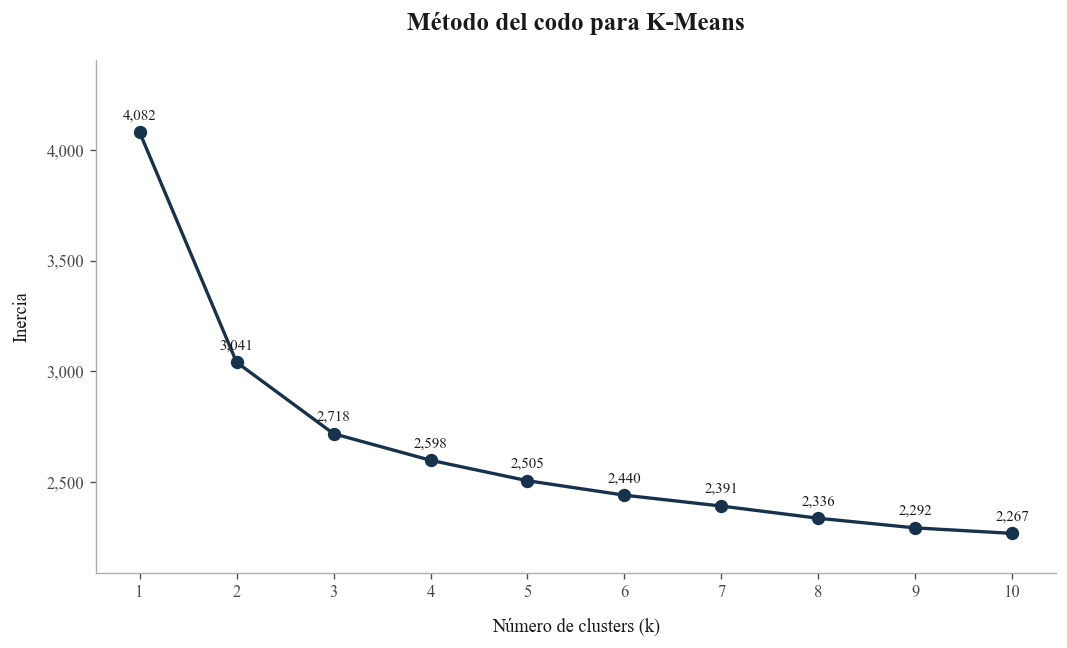

In [130]:
# Visualizamos la inercia obtenida para cada número de clusters
# con el propósito de construir el método del codo (Elbow Method)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters evaluado
# y en el eje vertical la inercia obtenida por K-Means.
ax.plot(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Método del codo para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Inercia",
    labelpad=10
)

# Indicamos explícitamente todos los valores de k evaluados
# para facilitar la lectura de la gráfica
ax.set_xticks(
    resultados_kmeans["Clusters"]
)

# Aplicamos separadores de miles al eje vertical
# para facilitar la lectura de los valores de inercia
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
# para mantener el mismo estilo visual utilizado en el EDA
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el valor de la inercia junto a cada punto
# para mostrar con claridad el resultado obtenido para cada k
for k, inercia in zip(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"]
):
    ax.text(
        k,
        inercia + 45,
        f"{inercia:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )

# Dejamos un pequeño espacio adicional en la parte superior
# para que las etiquetas no queden pegadas al límite de la figura
ax.set_ylim(
    resultados_kmeans["Inercia"].min() * 0.92,
    resultados_kmeans["Inercia"].max() * 1.08
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_metodo_codo"
)

# Mostramos la figura
plt.show()

**Interpretación del método del codo (K-Means)**

La gráfica muestra que la mayor reducción de la inercia ocurre al pasar de **1 a 2 clusters**, disminuyendo de 4,081.88 a 3,041.10. A partir de este punto, la reducción continúa, pero de manera considerablemente menor. Por ello, el método del codo sugiere que **2 clusters constituye una alternativa razonable**, ya que aumentar el número de grupos produce mejoras cada vez más pequeñas en la compactación de las empresas.

### Coeficiente de Silhouette

Como segundo criterio, se comparan los coeficientes de Silhouette obtenidos para las configuraciones de **k = 2 a k = 10**, con el propósito de evaluar la cohesión interna y la separación entre los grupos identificados.

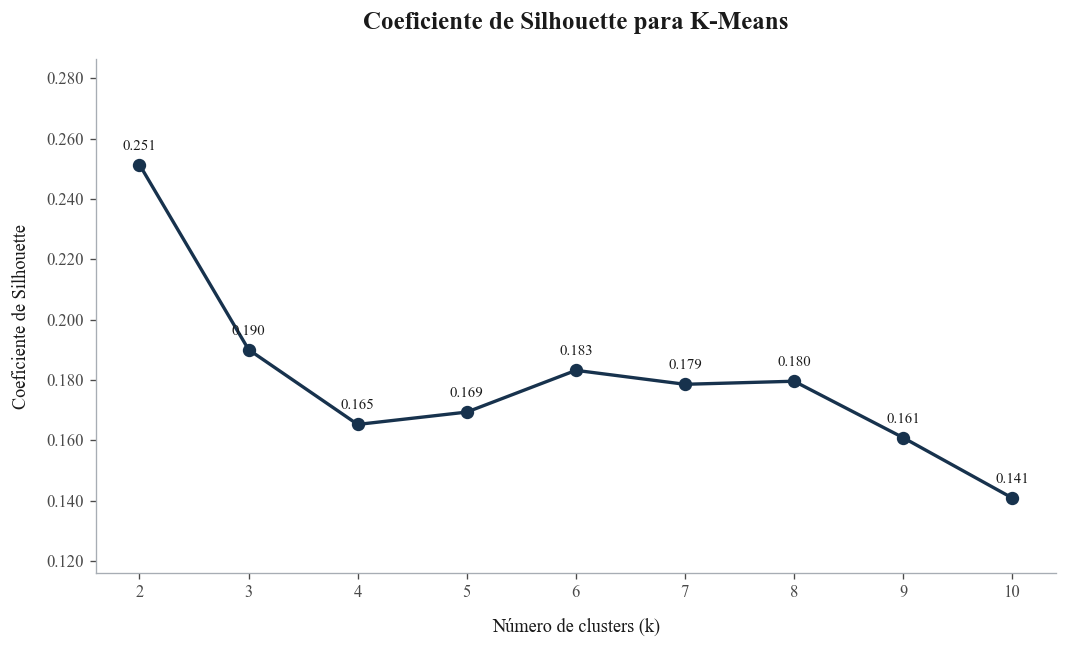

In [131]:
# Preparamos los resultados utilizados en la gráfica de Silhouette.
# Se excluye k = 1 porque el coeficiente requiere
# la existencia de al menos dos clusters.

resultados_silhouette = (
    resultados_kmeans
    .dropna(subset=["Silhouette"])
    .copy()
)

# Visualizamos el coeficiente de Silhouette obtenido
# para cada número de clusters evaluado

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters
# y en el eje vertical el coeficiente de Silhouette.
ax.plot(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Coeficiente de Silhouette para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Coeficiente de Silhouette",
    labelpad=10
)

# Indicamos explícitamente los valores de k evaluados
ax.set_xticks(
    resultados_silhouette["Clusters"]
)

# Mostramos tres decimales en el eje vertical
# para facilitar la comparación entre configuraciones
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:.3f}")
)

# Eliminamos los bordes que no aportan información
# manteniendo el mismo formato utilizado en las demás figuras
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el coeficiente obtenido junto a cada punto
# para mostrar con claridad las diferencias entre valores de k
for k, silhouette in zip(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"]
):
    ax.text(
        k,
        silhouette + 0.004,
        f"{silhouette:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )


# Dejamos un pequeño espacio adicional alrededor de los valores
# para evitar que las etiquetas queden pegadas a los límites
ax.set_ylim(
    resultados_silhouette["Silhouette"].min() - 0.025,
    resultados_silhouette["Silhouette"].max() + 0.035
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_coeficiente_silhouette"
)

# Mostramos la figura
plt.show()

**Interpretación del coeficiente de Silhouette (K-Means)**

El coeficiente de Silhouette alcanza su valor más alto con **2 clusters (0.251)**. Para configuraciones con un mayor número de grupos, el coeficiente disminuye y no vuelve a alcanzar este nivel. Esto indica que, entre las configuraciones evaluadas, la solución con **2 clusters presenta la mejor combinación de cohesión interna y separación entre grupos**. Sin embargo, el valor obtenido es moderado, por lo que los grupos no presentan una separación completamente marcada.

**Configuraciones candidatas**

En conjunto, tanto el método del codo como el coeficiente de Silhouette señalan a **k = 2** como la configuración cuantitativamente más favorable entre las evaluadas. Sin embargo, dado que el objetivo del análisis no consiste únicamente en maximizar la separación entre grupos, sino también en identificar perfiles de divulgación útiles e interpretables, se examinan adicionalmente las soluciones con **k = 3 y k = 4**.

Esta comparación permite evaluar si incorporar grupos adicionales revela perfiles de empresas que no son visibles con dos clusters, particularmente empresas con niveles muy bajos de divulgación.

### Comparación de las soluciones con 2, 3 y 4 clusters

Para complementar los criterios cuantitativos anteriores, se comparan las soluciones obtenidas con **2, 3 y 4 clusters**. Para cada configuración se revisa el número de empresas asignadas a cada grupo y su nivel general de divulgación.

In [132]:
# Comparamos las soluciones de K-Means con 2, 3 y 4 clusters
# para evaluar si un mayor número de grupos aporta perfiles
# adicionales que resulten útiles para la interpretación.

# Creamos una lista donde almacenaremos los resultados
comparacion_configuraciones = []

# Conservamos también los modelos y sus etiquetas
# para poder recuperarlos posteriormente si es necesario
modelos_configuraciones = {}
etiquetas_configuraciones = {}

# Evaluamos las tres configuraciones de interés
for k in [2, 3, 4]:

    # Ajustamos K-Means utilizando la misma configuración
    # empleada durante la evaluación anterior
    modelo = KMeans(
        n_clusters=k,
        random_state=SEMILLA,
        n_init=20
    )

    # Recuperamos el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Guardamos el modelo y las etiquetas
    modelos_configuraciones[k] = modelo
    etiquetas_configuraciones[k] = etiquetas

    # Calculamos el coeficiente de Silhouette
    silhouette = silhouette_score(
        X,
        etiquetas
    )

    # Calculamos el porcentaje general de divulgación
    # de cada empresa
    porcentaje_empresa = (
        X
        .mean(axis=1)
        .mul(100)
    )

    # Creamos una tabla auxiliar para resumir cada cluster
    resumen_auxiliar = pd.DataFrame({
        "Cluster": etiquetas,
        "Porcentaje_divulgacion": porcentaje_empresa.values
    })

    # Calculamos el tamaño y el nivel general
    # de divulgación de cada cluster
    resumen_auxiliar = (
        resumen_auxiliar
        .groupby(
            "Cluster",
            as_index=False
        )
        .agg(
            Empresas=(
                "Porcentaje_divulgacion",
                "size"
            ),
            Promedio_divulgacion=(
                "Porcentaje_divulgacion",
                "mean"
            ),
            Mediana_divulgacion=(
                "Porcentaje_divulgacion",
                "median"
            ),
            Minimo_divulgacion=(
                "Porcentaje_divulgacion",
                "min"
            ),
            Maximo_divulgacion=(
                "Porcentaje_divulgacion",
                "max"
            )
        )
    )

    # Incorporamos el número de clusters evaluado
    # y su coeficiente de Silhouette
    resumen_auxiliar.insert(
        0,
        "k",
        k
    )

    resumen_auxiliar[
        "Silhouette"
    ] = silhouette

    # Guardamos el resultado
    comparacion_configuraciones.append(
        resumen_auxiliar
    )

# Unimos los resultados de las tres configuraciones
comparacion_configuraciones = pd.concat(
    comparacion_configuraciones,
    ignore_index=True
)

# Redondeamos los valores para facilitar su lectura
columnas_redondear = [
    "Promedio_divulgacion",
    "Mediana_divulgacion",
    "Minimo_divulgacion",
    "Maximo_divulgacion",
    "Silhouette"
]

comparacion_configuraciones[
    columnas_redondear
] = (
    comparacion_configuraciones[
        columnas_redondear
    ]
    .round(3)
)

# Mostramos la comparación
display(
    comparacion_configuraciones
)

,k,Cluster,Empresas,Promedio_divulgacion,Mediana_divulgacion,Minimo_divulgacion,Maximo_divulgacion,Silhouette
0,2,0,108,44.512,40.826,25.688,80.734,0.251
1,2,1,142,10.815,9.174,0.000,28.440,0.251
2,3,0,91,5.232,4.587,0.000,15.596,0.190
3,3,1,52,55.928,52.294,38.532,80.734,0.190
4,3,2,107,27.652,26.606,14.679,45.872,0.190
5,4,0,76,22.767,22.018,11.927,35.780,0.165
6,4,1,87,4.809,3.670,0.000,13.761,0.165
7,4,2,31,62.208,65.138,46.789,80.734,0.165
8,4,3,56,40.465,38.991,29.358,50.459,0.165


**Interpretación de las configuraciones comparadas**

La comparación muestra una **gradación clara en el nivel general de divulgación** dentro de las tres configuraciones evaluadas. Con **k = 2** se identifican dos grupos amplios, con promedios de **10.82% y 44.51%**. Al utilizar **k = 3**, la separación se vuelve más detallada y permite distinguir un perfil de **muy baja divulgación** (5.23%, 91 empresas), uno de **divulgación intermedia** (27.65%, 107 empresas) y uno de **mayor divulgación** (55.93%, 52 empresas).

Con **k = 4**, el nivel general de divulgación se subdivide en cuatro grupos, con promedios de **4.81%, 22.77%, 40.47% y 62.21%**. Esta configuración ofrece una segmentación todavía más detallada del mismo gradiente general de divulgación.

Aunque **k = 2 presenta el coeficiente de Silhouette más alto (0.251)**, seguido de **k = 3 (0.190)** y **k = 4 (0.165)**, la solución con **k = 3** aporta una segmentación más detallada al identificar específicamente un grupo de empresas con niveles muy bajos de divulgación. Por esta razón, **k = 3 se conserva como solución candidata para continuar evaluando su estabilidad y utilidad interpretativa**.

### Evaluación de la estabilidad de K-Means

Una vez seleccionado **k = 3** como solución candidata para continuar el análisis, se evalúa su estabilidad ante distintas inicializaciones del algoritmo. K-Means puede producir resultados diferentes dependiendo de la posición inicial de los centroides, por lo que se repite el agrupamiento utilizando distintas semillas aleatorias.

Para comparar las asignaciones obtenidas se utiliza el **Adjusted Rand Index (ARI)**, que mide el grado de coincidencia entre dos agrupamientos considerando qué empresas permanecen juntas en los mismos grupos. Un valor cercano a **1** indica que ambas soluciones presentan prácticamente la misma estructura de agrupamiento, independientemente del número utilizado para identificar cada cluster.

La solución obtenida con la semilla definida para el análisis se utiliza como referencia y se compara con los resultados generados mediante distintas semillas.

In [133]:
# Evaluamos la estabilidad de la solución candidata de K-Means
# utilizando distintas semillas aleatorias

# Definimos el número de clusters seleccionado como candidato
# a partir de la comparación cuantitativa e interpretativa
K_CANDIDATO = 3

# Construimos primero una solución de referencia utilizando
# la semilla definida al inicio del notebook
modelo_referencia = KMeans(

    # Utilizamos k = 3 como número de clusters candidato
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija del análisis
    random_state=SEMILLA,

    # Ejecutamos K-Means 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo de referencia a los 109 indicadores
# y recuperamos el cluster asignado a cada empresa
etiquetas_referencia = modelo_referencia.fit_predict(X)

# Definimos distintas semillas para comprobar si la estructura
# de los grupos cambia ante diferentes inicializaciones
semillas_estabilidad = [
    1, 5, 10, 15, 20,
    25, 30, 35, 40, 45
]

# Creamos una lista vacía donde almacenaremos
# el resultado correspondiente a cada semilla
resultados_estabilidad = []

# Repetimos K-Means utilizando cada una de las semillas definidas
for semilla in semillas_estabilidad:

    # Construimos un nuevo modelo manteniendo exactamente
    # k = 3 y modificando únicamente la semilla aleatoria
    modelo = KMeans(

        # Mantenemos fijo el número de clusters candidato
        n_clusters=K_CANDIDATO,

        # Cambiamos la semilla en cada repetición
        random_state=semilla,

        # Mantenemos el mismo número de inicializaciones
        # utilizado durante la evaluación anterior
        n_init=20
    )

    # Ajustamos el modelo y recuperamos el cluster
    # asignado a cada una de las 250 empresas
    etiquetas = modelo.fit_predict(X)

    # Calculamos el Adjusted Rand Index (ARI) comparando
    # esta solución con la solución de referencia
    # Un valor cercano a 1 indica que ambas soluciones
    # agrupan a las empresas prácticamente de la misma manera.
    ari = adjusted_rand_score(
        etiquetas_referencia,
        etiquetas
    )

    # Guardamos la semilla utilizada y el nivel
    # de coincidencia obtenido respecto a la referencia
    resultados_estabilidad.append({
        "Semilla": semilla,
        "ARI": ari
    })

# Convertimos los resultados en un DataFrame
# para facilitar su revisión
resultados_estabilidad = pd.DataFrame(
    resultados_estabilidad
)

# Mostramos los resultados de la evaluación de estabilidad
display(resultados_estabilidad)

,Semilla,ARI
0,1,0.973
1,5,1.000
2,10,0.973
3,15,1.000
4,20,1.000
5,25,1.000
6,30,1.000
7,35,1.000
8,40,1.000
9,45,1.000


Los valores del **Adjusted Rand Index (ARI)** se encuentran entre **0.973 y 1.000**, lo que indica un nivel muy alto de coincidencia entre las agrupaciones obtenidas con distintas semillas. En **8 de las 10 configuraciones evaluadas** se reprodujo exactamente la solución de referencia (**ARI = 1.000**), mientras que las dos restantes alcanzaron un valor de **0.973**. Estos resultados muestran que la solución de **K-Means con k = 3 es estable ante diferentes inicializaciones del algoritmo**, por lo que la formación de los tres grupos no depende de manera importante de la semilla utilizada.

### Recuperación de la solución candidata de K-Means

Después de seleccionar **k = 3** como número de clusters candidato y comprobar que la solución es estable ante distintas inicializaciones, se ajusta nuevamente K-Means utilizando la semilla definida para el análisis.

El objetivo de esta etapa es recuperar la asignación correspondiente a la solución candidata de K-Means y conservarla junto con la información descriptiva de las empresas para realizar posteriormente la interpretación de los perfiles identificados.

In [134]:
# Ajustamos nuevamente K-Means utilizando
# la configuración candidata seleccionada

# Construimos la solución candidata de K-Means
# con tres clusters
modelo_kmeans_candidato = KMeans(

    # Utilizamos el número de clusters candidato
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija definida
    # al inicio del notebook
    random_state=SEMILLA,

    # Ejecutamos el algoritmo 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo a los 109 indicadores binarios
# y recuperamos el cluster asignado a cada empresa
clusters_kmeans = modelo_kmeans_candidato.fit_predict(X)

# Creamos una copia de la información descriptiva
# de las empresas para conservar sus nombres y país de sede
resultado_kmeans = informacion_empresas.copy()

# Incorporamos el cluster asignado por K-Means
# a cada una de las 250 empresas
resultado_kmeans["Cluster_KMeans"] = clusters_kmeans

# Mostramos las primeras observaciones para verificar
# que la asignación se haya incorporado correctamente
display(
    resultado_kmeans.head()
)

,Company,Pais_sede,Cluster_KMeans
0,AJIO,India,0
1,ALDO,Canadá,2
2,Abercrombie & Fitch,Estados Unidos,2
3,Adidas AG,Alemania,1
4,Aeropostale Inc.,Estados Unidos,0


In [135]:
# Revisamos el número de empresas asignadas
# a cada uno de los clusters identificados

distribucion_clusters_kmeans = (
    resultado_kmeans["Cluster_KMeans"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Empresas")
)

display(
    distribucion_clusters_kmeans
)

,Cluster,Empresas
0,0,91
1,1,52
2,2,107


In [136]:
# Exportamos la asignación de clusters obtenida
# para conservarla y utilizarla posteriormente
# durante la interpretación de los perfiles.

resultado_kmeans.to_csv(
    ruta_datos / "resultado_kmeans_clusters.csv",
    index=False
)

print(
    "Resultado de K-Means exportado correctamente."
)

Resultado de K-Means exportado correctamente.


### Interpretación de los perfiles obtenidos con K-Means

Una vez recuperada la asignación de las empresas a los tres clusters, se analizan las características de cada grupo con el propósito de identificar los patrones de divulgación que los distinguen. La interpretación se realiza en distintos niveles: primero se compara el nivel general de divulgación y el tamaño de los grupos; posteriormente se analizan las diferencias entre las categorías **Environment, Social y Governance** y, finalmente, se identifican los indicadores que presentan las mayores diferencias entre los clusters. A partir de estos resultados se construye una descripción general de cada perfil de transparencia.

**Distribución y nivel general de divulgación**

In [137]:
# Calculamos el porcentaje general de divulgación de cada empresa

# Como los 109 indicadores están codificados como 0 y 1,
# la media de cada fila representa la proporción de indicadores
# para los que cada empresa divulga información.

porcentaje_divulgacion_empresa = (
    X
    .mean(axis=1)
    .mul(100)
)

# Creamos una copia de la tabla que contiene
# la empresa, su país de sede y el cluster asignado
analisis_perfiles_kmeans = resultado_kmeans.copy()

# Incorporamos el porcentaje general de divulgación
# correspondiente a cada empresa.
analisis_perfiles_kmeans["Porcentaje_divulgacion"] = (
    porcentaje_divulgacion_empresa.values
)

# Calculamos el promedio de divulgación dentro de cada cluster
# y el número de empresas que lo componen
resumen_general_clusters = (
    analisis_perfiles_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False
    )
    .agg(
        Empresas=("Company", "nunique"),
        Porcentaje_promedio_divulgacion=(
            "Porcentaje_divulgacion",
            "mean"
        )
    )
)

# Redondeamos el porcentaje para facilitar su lectura
resumen_general_clusters[
    "Porcentaje_promedio_divulgacion"
] = (
    resumen_general_clusters[
        "Porcentaje_promedio_divulgacion"
    ]
    .round(2)
)

# Mostramos el resultado.
display(resumen_general_clusters)

,Cluster_KMeans,Empresas,Porcentaje_promedio_divulgacion
0,0,91,5.230
1,1,52,55.930
2,2,107,27.650


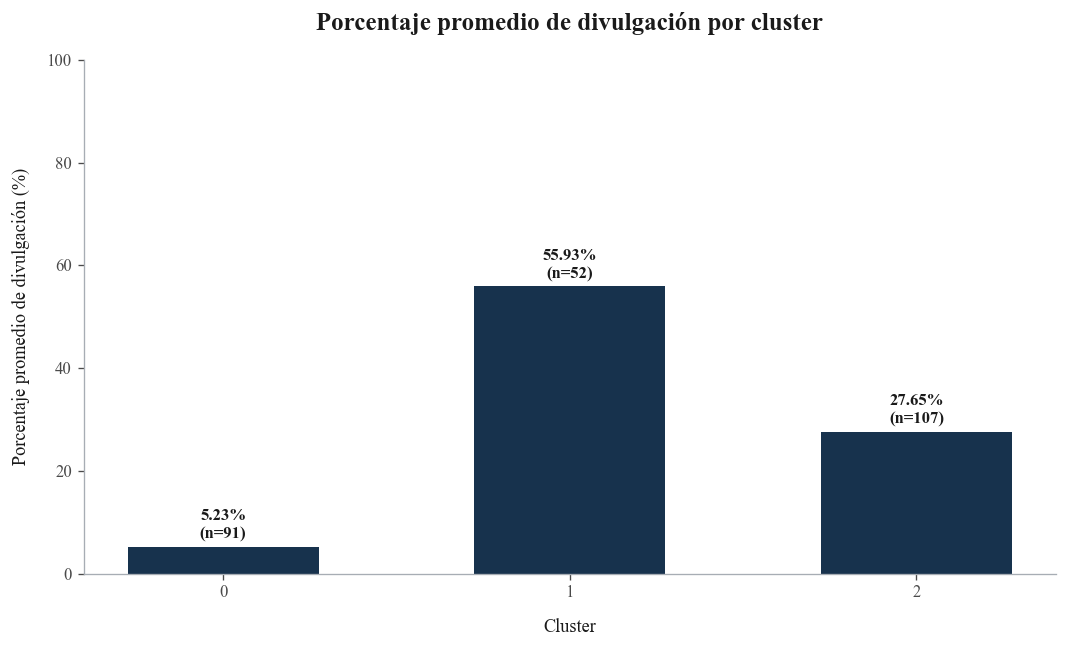

In [138]:
# Visualizamos el porcentaje promedio general de divulgación
# correspondiente a cada cluster identificado por K-Means

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos una gráfica de barras donde cada barra
# representa uno de los tres clusters identificados
barras = ax.bar(
    resumen_general_clusters["Cluster_KMeans"].astype(str),
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    color=AZUL_MARINO,
    width=0.55
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por cluster",
    pad=18
)

ax.set_xlabel(
    "Cluster",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
# para conservar el mismo formato visual utilizado
# en las figuras anteriores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos sobre cada barra el porcentaje promedio
# y el número de empresas que componen el cluster
for barra, porcentaje, empresas in zip(
    barras,
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    resumen_general_clusters["Empresas"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{porcentaje:.2f}%\n(n={empresas})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Establecemos el eje vertical entre 0 y 100,
# ya que se representa un porcentaje de divulgación
ax.set_ylim(0, 100)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_divulgacion_promedio_clusters"
)

# Mostramos la figura
plt.show()

Los números asignados a los clusters funcionan únicamente como etiquetas y no representan un orden en el nivel de divulgación. De acuerdo con sus resultados, el **Cluster 0**, integrado por **91 empresas**, presenta el nivel promedio más bajo de divulgación, con **5.23%**. El **Cluster 2**, compuesto por **107 empresas**, registra un nivel intermedio de **27.65%**, mientras que el **Cluster 1**, con **52 empresas**, presenta el nivel más alto, con **55.93%**.

Por lo tanto, la solución con tres clusters permite distinguir tres perfiles generales de transparencia: **muy baja divulgación, divulgación intermedia y mayor divulgación**. A continuación, se analiza si esta gradación también se observa en las categorías **Environment, Social y Governance**.

**Perfil de divulgación por categoría temática**

Para comprender con mayor detalle las diferencias entre los perfiles identificados, se compara el porcentaje promedio de divulgación de cada cluster en las categorías **Environment, Social y Governance**. Este análisis permite determinar si la separación observada entre los grupos responde únicamente a una diferencia general en el nivel de divulgación o si existen patrones distintos entre las categorías temáticas.

In [139]:
# Cargamos el diccionario de indicadores para recuperar
# la categoría temática correspondiente a cada variable

diccionario_indicadores = pd.read_excel(
    ruta_datos / "diccionario_indicadores.xlsx"
)

# Conservamos únicamente la información necesaria:
# el nombre original del indicador y su categoría temática
categorias_indicadores = (
    diccionario_indicadores[
        ["Indicador original", "Categoría temática"]
    ]
    .drop_duplicates()
)

# Creamos un diccionario que relaciona cada indicador
# con su categoría temática
mapa_categorias = dict(
    zip(
        categorias_indicadores["Indicador original"],
        categorias_indicadores["Categoría temática"]
    )
)

# Verificamos que todos los indicadores utilizados en X
# tengan una categoría temática asignada
indicadores_sin_categoria = [
    indicador
    for indicador in X.columns
    if indicador not in mapa_categorias
]

print(
    "Indicadores sin categoría temática:",
    len(indicadores_sin_categoria)
)

# Creamos una copia de la matriz de indicadores
# e incorporamos el cluster asignado a cada empresa
X_clusters = X.copy()

X_clusters["Cluster_KMeans"] = clusters_kmeans

# Transformamos la matriz de formato ancho a formato largo
# De esta manera, cada fila representa la combinación:
# empresa - indicador - cluster
X_largo = (
    X_clusters
    .reset_index()
    .melt(
        id_vars=["index", "Cluster_KMeans"],
        var_name="Indicador",
        value_name="Divulga"
    )
)

# Incorporamos la categoría temática correspondiente
# a cada indicador
X_largo["Categoria"] = (
    X_largo["Indicador"]
    .map(mapa_categorias)
)

# Conservamos únicamente las tres categorías utilizadas
# para la interpretación de los perfiles
X_largo_esg = X_largo[
    X_largo["Categoria"].isin(
        ["Environment", "Social", "Governance"]
    )
].copy()

# Calculamos el porcentaje promedio de divulgación
# de cada cluster dentro de cada categoría temática
perfil_categorias_kmeans = (
    X_largo_esg
    .groupby(
        ["Cluster_KMeans", "Categoria"],
        as_index=False
    )
    ["Divulga"]
    .mean()
)

# Convertimos las proporciones a porcentajes
perfil_categorias_kmeans[
    "Porcentaje_divulgacion"
] = (
    perfil_categorias_kmeans["Divulga"]
    .mul(100)
    .round(2)
)

# Conservamos únicamente las columnas necesarias
# para presentar los resultados
perfil_categorias_kmeans = (
    perfil_categorias_kmeans[
        [
            "Cluster_KMeans",
            "Categoria",
            "Porcentaje_divulgacion"
        ]
    ]
)

# Mostramos los resultados
display(perfil_categorias_kmeans)

Indicadores sin categoría temática: 0


,Cluster_KMeans,Categoria,Porcentaje_divulgacion
0,0,Environment,3.510
1,0,Governance,8.130
2,0,Social,5.490
3,1,Environment,58.860
4,1,Governance,60.000
5,1,Social,51.720
6,2,Environment,29.020
7,2,Governance,35.000
8,2,Social,23.420


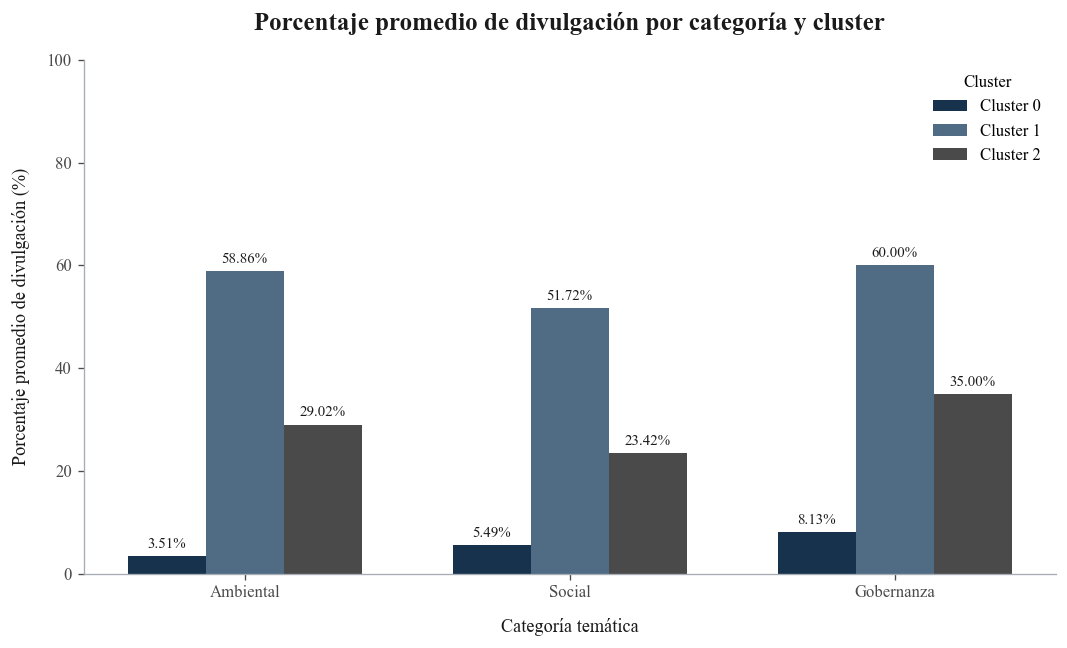

In [140]:
# Visualizamos el porcentaje promedio de divulgación
# de cada cluster por categoría temática

# Reorganizamos la tabla para facilitar la construcción
# de una gráfica de barras agrupadas
perfil_grafica = (
    perfil_categorias_kmeans
    .pivot(
        index="Categoria",
        columns="Cluster_KMeans",
        values="Porcentaje_divulgacion"
    )
    .loc[
        ["Environment", "Social", "Governance"]
    ]
)

# Definimos las posiciones de las categorías
posiciones = np.arange(
    len(perfil_grafica.index)
)

# Definimos el ancho de las barras
# para representar los tres clusters
ancho = 0.24

# Definimos los colores que utilizaremos
# para distinguir los tres grupos
colores_clusters = [
    AZUL_MARINO,
    AZUL_SECUNDARIO,
    GRIS_OSCURO
]

# Construimos la figura
fig, ax = plt.subplots(figsize=(9, 5.5))

# Calculamos las posiciones necesarias para centrar
# las tres barras alrededor de cada categoría
desplazamientos = [
    -ancho,
    0,
    ancho
]

# Guardamos los grupos de barras para poder
# incorporar posteriormente sus etiquetas
barras_clusters = []

# Graficamos los valores correspondientes
# a cada uno de los tres clusters
for cluster, desplazamiento, color in zip(
    [0, 1, 2],
    desplazamientos,
    colores_clusters
):
    barras = ax.bar(
        posiciones + desplazamiento,
        perfil_grafica[cluster],
        width=ancho,
        color=color,
        label=f"Cluster {cluster}"
    )

    barras_clusters.append(barras)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por categoría y cluster",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Incorporamos los nombres de las categorías
# utilizando su traducción al español
ax.set_xticks(posiciones)

ax.set_xticklabels(
    ["Ambiental", "Social", "Gobernanza"]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barras in barras_clusters:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            color=NEGRO
        )

# Establecemos el eje vertical entre 0 y 100
# porque los valores representan porcentajes
ax.set_ylim(0, 100)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster"
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_perfil_categorias_clusters"
)

# Mostramos la figura
plt.show()

Los tres clusters mantienen diferencias importantes en el **nivel de divulgación** dentro de las categorías analizadas. El **Cluster 0**, correspondiente al perfil de muy baja divulgación, registra **8.13% en Gobernanza, 5.49% en Social y 3.51% en Ambiental**. El **Cluster 2**, identificado como el perfil intermedio, presenta **35.00% en Gobernanza, 29.02% en Ambiental y 23.42% en Social**. Finalmente, el **Cluster 1**, correspondiente al perfil de mayor divulgación, alcanza **60.00% en Gobernanza, 58.86% en Ambiental y 51.72% en Social**.

En los tres grupos, **Gobernanza presenta el porcentaje de divulgación más alto**. Además, los niveles del Cluster 0 permanecen bajos en las tres categorías, los del Cluster 2 ocupan una posición intermedia y los del Cluster 1 son consistentemente mayores. Por lo tanto, la comparación por categoría refuerza la interpretación de que K-Means distingue principalmente a las empresas por la **intensidad general de su divulgación**, más que por perfiles temáticos opuestos.

**Indicadores que más diferencian los perfiles**

Después de comparar los niveles generales y las categorías temáticas, se analizan los **109 indicadores individuales** utilizados en el agrupamiento. Para cada indicador se compara el porcentaje de divulgación de los tres clusters y se calcula la diferencia entre el grupo con el porcentaje más alto y el grupo con el porcentaje más bajo. De esta manera, se identifican los indicadores en los que los perfiles presentan las mayores diferencias.

In [141]:
# Calculamos el porcentaje de divulgación de cada indicador
# dentro de los tres clusters identificados por K-Means

# Creamos una copia de la matriz de indicadores
# para incorporar la asignación de cluster de cada empresa
perfil_indicadores_kmeans = X.copy()

# Añadimos el cluster correspondiente a cada empresa
perfil_indicadores_kmeans["Cluster_KMeans"] = (
    clusters_kmeans
)

# Calculamos la media de cada indicador dentro de cada cluster
# Debido a que los indicadores están codificados como 0 y 1,
# la media representa la proporción de empresas del cluster
# que divulga la información correspondiente
promedio_indicadores_cluster = (
    perfil_indicadores_kmeans
    .groupby("Cluster_KMeans")
    .mean()
    .T
    .mul(100)
    .reset_index()
)

# Renombramos las columnas para facilitar su interpretación
promedio_indicadores_cluster.columns = [
    "Indicador",
    "Cluster_0",
    "Cluster_1",
    "Cluster_2"
]

# Incorporamos la categoría temática correspondiente
promedio_indicadores_cluster["Categoria"] = (
    promedio_indicadores_cluster["Indicador"]
    .map(mapa_categorias)
)

# Definimos las columnas correspondientes
# a los porcentajes de los tres clusters
columnas_clusters = [
    "Cluster_0",
    "Cluster_1",
    "Cluster_2"
]

# Identificamos, para cada indicador, el porcentaje
# de divulgación más alto y el más bajo
promedio_indicadores_cluster[
    "Porcentaje_maximo"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .max(axis=1)
)

promedio_indicadores_cluster[
    "Porcentaje_minimo"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .min(axis=1)
)

# Calculamos la mayor diferencia observada
# entre los tres clusters para cada indicador
promedio_indicadores_cluster[
    "Diferencia_max_min_pp"
] = (
    promedio_indicadores_cluster[
        "Porcentaje_maximo"
    ]
    -
    promedio_indicadores_cluster[
        "Porcentaje_minimo"
    ]
)

# Identificamos qué cluster presenta
# el porcentaje máximo y cuál el mínimo
promedio_indicadores_cluster[
    "Cluster_mayor"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .idxmax(axis=1)
)

promedio_indicadores_cluster[
    "Cluster_menor"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .idxmin(axis=1)
)

# Ordenamos los indicadores desde la mayor
# hasta la menor diferencia entre perfiles
promedio_indicadores_cluster = (
    promedio_indicadores_cluster
    .sort_values(
        "Diferencia_max_min_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

# Redondeamos los porcentajes y las diferencias
# para facilitar la presentación de los resultados
columnas_redondear = [
    "Cluster_0",
    "Cluster_1",
    "Cluster_2",
    "Porcentaje_maximo",
    "Porcentaje_minimo",
    "Diferencia_max_min_pp"
]

promedio_indicadores_cluster[
    columnas_redondear
] = (
    promedio_indicadores_cluster[
        columnas_redondear
    ]
    .round(2)
)

# Conservamos los diez indicadores
# con mayor diferencia entre los perfiles
top_10_diferencias_kmeans = (
    promedio_indicadores_cluster
    .head(10)
    .copy()
)

# Mostramos los resultados
display(
    top_10_diferencias_kmeans[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Diferencia_max_min_pp",
            "Cluster_mayor",
            "Cluster_menor"
        ]
    ]
)

,Indicador,Categoria,Cluster_0,Cluster_1,Cluster_2,Diferencia_max_min_pp,Cluster_mayor,Cluster_menor
0,Fashion Revolution+Describes Environmental Due...,Environment,2.200,100.000,64.490,97.800,Cluster_1,Cluster_0
1,Fashion Revolution+Discloses Progress on Susta...,Environment,3.300,98.080,48.600,94.780,Cluster_1,Cluster_0
2,"Fashion Revolution+Scope, Process and Accredit...",Environment,5.490,98.080,49.530,92.580,Cluster_1,Cluster_0
3,Fashion Revolution+Prevention Mitigation and R...,Social,0.000,92.310,36.450,92.310,Cluster_1,Cluster_0
4,Fashion Revolution+Human Rights Risks Impacts ...,Social,5.490,96.150,71.030,90.660,Cluster_1,Cluster_0
5,Fashion Revolution+Sustainable Materials Strategy,Environment,9.890,100.000,62.620,90.110,Cluster_1,Cluster_0
6,Fashion Revolution+Environmental Risks Impacts...,Governance,1.100,90.380,42.060,89.290,Cluster_1,Cluster_0
7,Fashion Revolution+Discloses Progress to Reduc...,Environment,0.000,88.460,19.630,88.460,Cluster_1,Cluster_0
8,Fashion Revolution+Reports on Efforts to Impro...,Social,2.200,90.380,47.660,88.190,Cluster_1,Cluster_0
9,Fashion Revolution+Discloses Approach to Recru...,Social,4.400,92.310,47.660,87.910,Cluster_1,Cluster_0


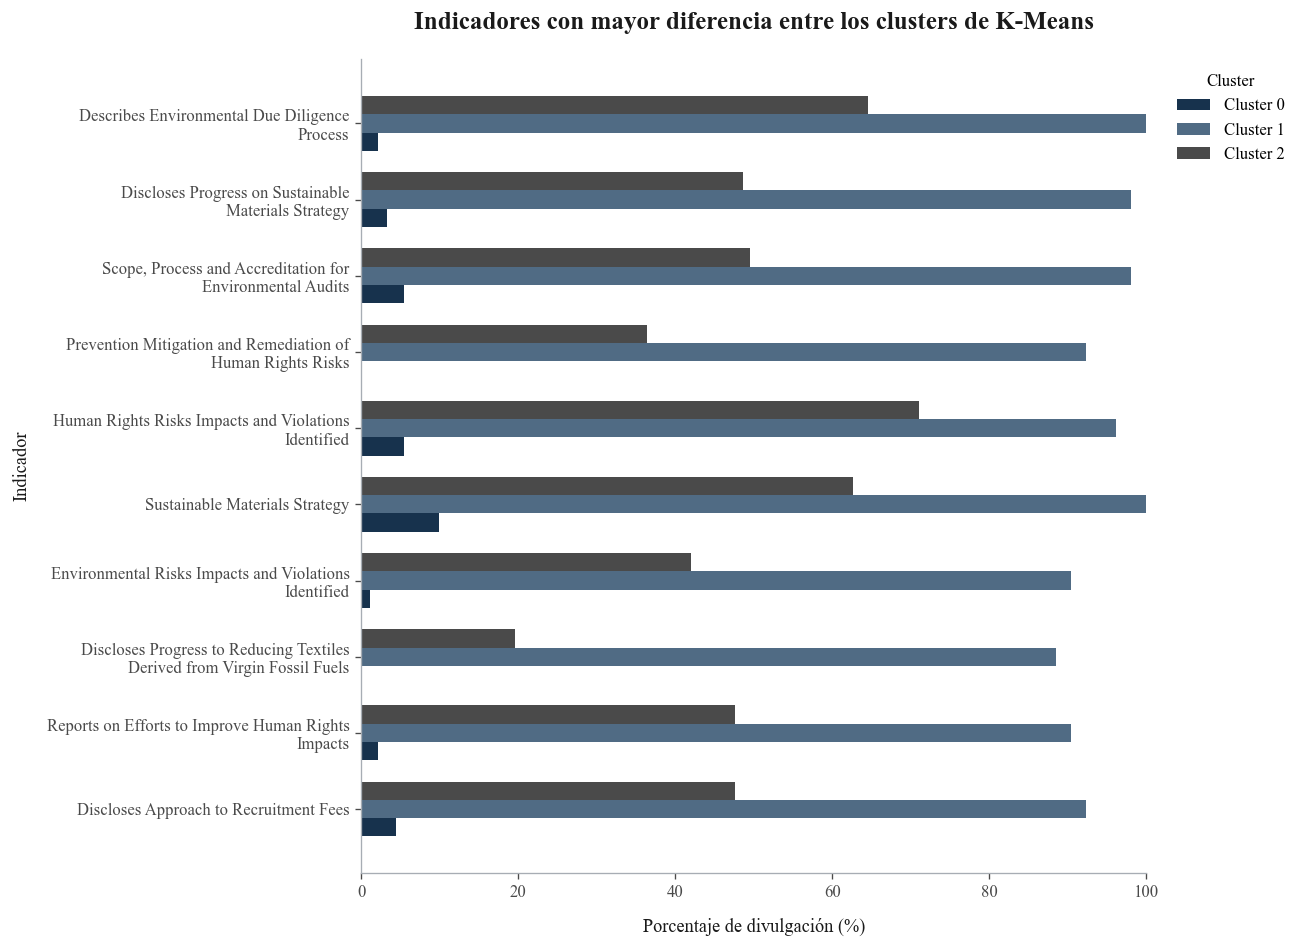

In [142]:
# Visualizamos los diez indicadores con mayor diferencia
# entre los tres perfiles identificados por K-Means

# Creamos una copia para preparar la información
# que será utilizada únicamente en la figura
top_10_grafica_kmeans = (
    top_10_diferencias_kmeans
    .copy()
)

# Eliminamos el prefijo "Fashion Revolution+"
# para hacer más legibles los nombres de los indicadores
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Dividimos automáticamente los nombres largos
# en varias líneas para facilitar su lectura
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador_visual"]
    .apply(
        lambda texto: textwrap.fill(
            texto,
            width=42
        )
    )
)

# Ordenamos los indicadores de acuerdo con la
# diferencia máxima observada entre los clusters
top_10_grafica_kmeans = (
    top_10_grafica_kmeans
    .sort_values(
        "Diferencia_max_min_pp",
        ascending=True
    )
    .reset_index(drop=True)
)

# Definimos las posiciones de los indicadores
posiciones = np.arange(
    len(top_10_grafica_kmeans)
)

# Definimos el alto de cada barra
alto = 0.24

# Construimos la figura
fig, ax = plt.subplots(
    figsize=(11, 8)
)

# Representamos el porcentaje de divulgación
# correspondiente a cada cluster
barras_0 = ax.barh(
    posiciones - alto,
    top_10_grafica_kmeans["Cluster_0"],
    height=alto,
    color=AZUL_MARINO,
    label="Cluster 0"
)

barras_1 = ax.barh(
    posiciones,
    top_10_grafica_kmeans["Cluster_1"],
    height=alto,
    color=AZUL_SECUNDARIO,
    label="Cluster 1"
)

barras_2 = ax.barh(
    posiciones + alto,
    top_10_grafica_kmeans["Cluster_2"],
    height=alto,
    color=GRIS_OSCURO,
    label="Cluster 2"
)

# Incorporamos los nombres de los indicadores
ax.set_yticks(posiciones)

ax.set_yticklabels(
    top_10_grafica_kmeans["Indicador_visual"]
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Indicadores con mayor diferencia entre los clusters de K-Means",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Establecemos el eje horizontal entre 0 y 100
ax.set_xlim(0, 100)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_top_10_diferencias_indicadores"
)

# Mostramos la figura
plt.show()

Los diez indicadores con mayores diferencias entre los perfiles presentan brechas de entre **87.91 y 97.80 puntos porcentuales** entre el cluster con mayor y menor divulgación. De estos indicadores, **cinco pertenecen a Environment, cuatro a Social y uno a Governance**, por lo que las diferencias más amplias se concentran principalmente en información ambiental y social.

Los indicadores que más separan a los perfiles son *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental), *Discloses Progress on Sustainable Materials Strategy* (divulga avances en la estrategia de materiales sostenibles), *Scope, Process and Accreditation for Environmental Audits* (alcance, proceso y acreditación de auditorías ambientales), *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos), *Human Rights Risks Impacts and Violations Identified* (riesgos, impactos y violaciones de derechos humanos identificados), *Sustainable Materials Strategy* (estrategia de materiales sostenibles), *Environmental Risks Impacts and Violations Identified* (riesgos, impactos y violaciones ambientales identificados), *Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels* (divulga avances en la reducción de textiles derivados de combustibles fósiles vírgenes), *Reports on Efforts to Improve Human Rights Impacts* (reporta esfuerzos para mejorar los impactos en derechos humanos) y *Discloses Approach to Recruitment Fees* (divulga su enfoque sobre tarifas de contratación).

En estos diez indicadores, el **Cluster 1**, correspondiente al perfil de mayor divulgación, presenta porcentajes de entre **88.46% y 100%**, mientras que el **Cluster 0**, correspondiente al perfil de muy baja divulgación, registra valores de entre **0% y 9.89%**. Por lo tanto, la diferencia entre ambos perfiles no se limita al porcentaje general de divulgación: las empresas del Cluster 1 publican con mucha mayor frecuencia información relacionada con **debida diligencia, auditorías, identificación de riesgos e impactos, estrategias, medidas de respuesta y seguimiento de avances**, mientras que esta información aparece de manera muy limitada entre las empresas del Cluster 0.

El **Cluster 2** muestra un comportamiento intermedio, pero no uniforme. Dentro de estos diez indicadores, sus porcentajes varían entre **19.63% y 71.03%**. Por ejemplo, alcanza **71.03%** en *Human Rights Risks Impacts and Violations Identified* (riesgos, impactos y violaciones de derechos humanos identificados), **64.49%** en *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental) y **62.62%** en *Sustainable Materials Strategy* (estrategia de materiales sostenibles). En contraste, registra **19.63%** en *Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels* (divulga avances en la reducción de textiles derivados de combustibles fósiles vírgenes) y **36.45%** en *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos). Esto permite caracterizar al perfil intermedio como un grupo que, al menos entre los indicadores que más diferencian a los clusters, presenta niveles relativamente altos en algunos procesos de identificación y debida diligencia, pero una divulgación menor en determinadas medidas y avances específicos.

Esta comparación muestra una aportación específica del clustering frente al análisis exploratorio general. Mientras que el EDA permite identificar **qué indicadores presentan mayor o menor divulgación en el conjunto de las 250 empresas**, el agrupamiento permite observar **cómo se distribuye esa divulgación entre perfiles empresariales con patrones distintos**. Así, un indicador con un determinado porcentaje global puede presentar comportamientos muy diferentes entre grupos: puede ser divulgado por casi todas las empresas del perfil de mayor divulgación y, al mismo tiempo, estar prácticamente ausente en el perfil de muy baja divulgación. Por lo tanto, el clustering permite pasar de una lectura agregada de los indicadores a una **lectura diferenciada de los patrones de divulgación entre empresas**, revelando heterogeneidad que el porcentaje global por sí solo no muestra.

In [120]:
# Verificamos si la gradación general observada entre los clusters
# también se mantiene al analizar los 109 indicadores individuales

# De acuerdo con los niveles generales identificados:
# Cluster 1 = mayor divulgación
# Cluster 2 = divulgación intermedia
# Cluster 0 = muy baja divulgación

promedio_indicadores_cluster[
    "Orden_esperado"
] = (
    (
        promedio_indicadores_cluster["Cluster_1"]
        >=
        promedio_indicadores_cluster["Cluster_2"]
    )
    &
    (
        promedio_indicadores_cluster["Cluster_2"]
        >=
        promedio_indicadores_cluster["Cluster_0"]
    )
)

# Contamos cuántos indicadores mantienen
# la gradación general entre los tres perfiles
indicadores_orden_esperado = (
    promedio_indicadores_cluster[
        "Orden_esperado"
    ]
    .sum()
)

indicadores_total = len(
    promedio_indicadores_cluster
)

print(
    "Indicadores que mantienen el orden "
    "Cluster 1 >= Cluster 2 >= Cluster 0:",
    indicadores_orden_esperado,
    "de",
    indicadores_total
)

# Identificamos los indicadores en los que
# la gradación general no se mantiene
indicadores_excepciones = (
    promedio_indicadores_cluster[
        ~promedio_indicadores_cluster[
            "Orden_esperado"
        ]
    ]
    .copy()
)

print(
    "Indicadores que no mantienen este orden:",
    len(indicadores_excepciones)
)

display(
    indicadores_excepciones[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
)

Indicadores que mantienen el orden Cluster 1 >= Cluster 2 >= Cluster 0: 106 de 109
Indicadores que no mantienen este orden: 3


,Indicador,Categoria,Cluster_0,Cluster_1,Cluster_2
69,Fashion Revolution+Publishes Gender-based Labo...,Social,1.100,36.540,0.000
88,Fashion Revolution+Publishes Racial Equality A...,Social,4.400,21.150,2.800
108,Fashion Revolution+Publishes Standard Supplier...,Governance,1.100,1.920,0.000


La gradación general entre los perfiles se mantiene en **106 de los 109 indicadores analizados**: el **Cluster 1** presenta el mayor porcentaje de divulgación, el **Cluster 2** ocupa una posición intermedia y el **Cluster 0** registra el menor porcentaje.

Solo **3 indicadores** no siguen exactamente este orden: *Publishes Gender-based Labour Violations Data* (publica datos sobre violaciones laborales relacionadas con el género), *Publishes Racial Equality Actions* (publica acciones de igualdad racial) y *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores). En estos casos, el Cluster 1 continúa presentando el porcentaje más alto, pero el Cluster 2 registra un valor ligeramente inferior al Cluster 0.

En conjunto, este resultado muestra que la separación obtenida mediante K-Means corresponde de manera muy consistente a tres niveles de divulgación: **muy baja, intermedia y mayor divulgación**, más que a perfiles temáticos opuestos.

**Indicadores con mayor y menor divulgación dentro de cada perfil**

Para caracterizar con mayor precisión los perfiles identificados, se analizan los indicadores que presentan los porcentajes de divulgación más altos y más bajos dentro de cada cluster. Este análisis permite identificar qué información se publica con mayor frecuencia entre las empresas de cada perfil y qué temas presentan una divulgación más limitada.

In [143]:
# Identificamos los indicadores con mayor y menor
# porcentaje de divulgación dentro de cada cluster

# Partimos de la tabla construida previamente,
# que contiene el porcentaje de divulgación
# de cada indicador en los tres clusters
columnas_perfiles = {
    0: "Cluster_0",
    1: "Cluster_1",
    2: "Cluster_2"
}

top_indicadores_por_cluster = {}
bottom_indicadores_por_cluster = {}

for cluster, columna in columnas_perfiles.items():

    # Diez indicadores con mayor porcentaje
    # de divulgación dentro del cluster
    top_indicadores_por_cluster[cluster] = (
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )

    # Diez indicadores con menor porcentaje
    # de divulgación dentro del cluster
    bottom_indicadores_por_cluster[cluster] = (
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=True
        )
        .head(10)
        .reset_index(drop=True)
    )

# Mostramos los resultados de cada perfil
for cluster in [0, 1, 2]:

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MAYOR DIVULGACIÓN"
    )

    display(
        top_indicadores_por_cluster[
            cluster
        ]
    )

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MENOR DIVULGACIÓN"
    )

    display(
        bottom_indicadores_por_cluster[
            cluster
        ]
    )


CLUSTER 0 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+Supply Chain Policies Are C...,Governance,42.860
1,Fashion Revolution+Grievance Mechanism - Direc...,Social,38.460
2,Fashion Revolution+Supply Chain Policies Align...,Governance,37.360
3,Fashion Revolution+New Production Facility Cri...,Social,34.070
4,Fashion Revolution+Grievance Mechanism - Suppl...,Social,26.370
5,Fashion Revolution+Remediation Process,Social,26.370
6,Fashion Revolution+Plan for Improving Environm...,Environment,26.370
7,Fashion Revolution+Implementation of Board Lev...,Governance,25.270
8,Fashion Revolution+Describes Human Rights Due ...,Social,23.080
9,Fashion Revolution+Accountable Board Member Id...,Governance,16.480



CLUSTER 0 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+Percentage of Audits includ...,Social,0.000
1,Fashion Revolution+Stakeholder Engagement in E...,Social,0.000
2,Fashion Revolution+Zero Deforestation Progress,Environment,0.000
3,Fashion Revolution+Discloses % of Circular Pro...,Environment,0.000
4,Fashion Revolution+Discloses Breakdown of Reus...,Environment,0.000
5,Fashion Revolution+Number or % of off-site wor...,Social,0.000
6,Fashion Revolution+Human Rights Risk Preventio...,Social,0.000
7,Fashion Revolution+Discloses Water-Related Ris...,Environment,0.000
8,Fashion Revolution+Protects Labour Costs in Pr...,Social,0.000
9,Fashion Revolution+Executive Pay Linked to Env...,Governance,0.000



CLUSTER 1 - INDICADORES CON MAYOR DIVULGACIÓN


...

,Indicador,Categoria,Cluster_1
0,Fashion Revolution+Publishes Standard Supplier...,Governance,1.920
1,Fashion Revolution+Commitment to Degrowth,Environment,1.920
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,1.920
3,Fashion Revolution+Discloses Progress toward t...,Social,3.850
4,Fashion Revolution+Publishes Percentage or Num...,Social,3.850
5,Fashion Revolution+Discloses Free on Board (FO...,Governance,3.850
6,Fashion Revolution+Discloses Strategy to Achie...,Social,5.770
7,Fashion Revolution+Discloses Number of Collect...,Social,5.770
8,Fashion Revolution+Discloses Percentage of Wor...,Environment,7.690
9,Fashion Revolution+Reports on Minimum Wage Pai...,Social,7.690



CLUSTER 2 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_2
0,Fashion Revolution+Plan for Improving Environm...,Environment,96.260
1,Fashion Revolution+Supply Chain Policies Align...,Governance,95.330
2,Fashion Revolution+Describes Human Rights Due ...,Social,89.720
3,Fashion Revolution+Implementation of Board Lev...,Governance,85.980
4,Fashion Revolution+Supply Chain Policies Are C...,Governance,85.980
5,Fashion Revolution+Discloses Content of Scope ...,Environment,84.110
6,Fashion Revolution+Reports on Efforts to Impro...,Environment,83.180
7,Fashion Revolution+Grievance Mechanism - Direc...,Social,79.440
8,Fashion Revolution+Accountable Board Member Id...,Governance,77.570
9,Fashion Revolution+Grievance Mechanism - Suppl...,Social,76.640



CLUSTER 2 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_2
0,Fashion Revolution+Publishes Standard Supplier...,Governance,0.000
1,Fashion Revolution+Publishes Gender-based Labo...,Social,0.000
2,Fashion Revolution+Discloses Number of Collect...,Social,0.000
3,Fashion Revolution+Discloses Percentage of Wor...,Environment,0.000
4,Fashion Revolution+Reports on Minimum Wage Pai...,Social,0.000
5,Fashion Revolution+Discloses Quantity of Order...,Social,0.000
6,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,0.930
7,Fashion Revolution+Publishes Percentage or Num...,Social,0.930
8,Fashion Revolution+Number or % of off-site wor...,Social,0.930
9,Fashion Revolution+Commitment to Degrowth,Environment,0.930


El análisis de los indicadores con mayor y menor divulgación permite precisar qué caracteriza a las empresas pertenecientes a cada perfil. Las diferencias no se limitan al porcentaje promedio general, sino también a **qué tipo de información aparece con mayor frecuencia y qué información permanece prácticamente ausente dentro de cada grupo**.

En el **Cluster 0**, correspondiente al perfil de muy baja divulgación, incluso los indicadores más frecuentes presentan porcentajes relativamente limitados. El valor más alto corresponde a *Supply Chain Policies Are Contractual* (las políticas de la cadena de suministro forman parte de los contratos con proveedores), con **42.86%**, seguido de *Grievance Mechanism – Direct Employees* (mecanismo de quejas para empleados directos), con **38.46%**, y *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), con **37.36%**. También aparecen entre los indicadores más divulgados *New Production Facility Criteria* (criterios para nuevas instalaciones de producción), *Grievance Mechanism – Supply Chain Workers* (mecanismo de quejas para trabajadores de la cadena de suministro), *Remediation Process* (proceso de remediación) y *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos).

Este resultado muestra que el perfil de muy baja divulgación **no implica ausencia absoluta de información**. Cuando estas empresas divulgan, la información se concentra principalmente en determinadas políticas, responsabilidades y mecanismos formales. Sin embargo, **ninguno de sus diez indicadores más frecuentes alcanza siquiera el 50% de las empresas del cluster**, y sus diez indicadores con menor divulgación registran **0%**. Por lo tanto, la característica principal de este perfil es una divulgación reducida y selectiva, con numerosos temas completamente ausentes.

El **Cluster 1**, correspondiente al perfil de mayor divulgación, presenta una estructura claramente distinta. Siete de sus diez indicadores más frecuentes alcanzan **100% de divulgación**, incluyendo *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental), *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), *Sustainable Materials Strategy* (estrategia de materiales sostenibles), *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos), *New Production Facility Criteria* (criterios para nuevas instalaciones de producción), *Plan for Improving Environmental Impacts* (plan para mejorar los impactos ambientales) y *Reports on Efforts to Improve Environmental Impacts* (reporta esfuerzos para mejorar los impactos ambientales). Los tres restantes alcanzan **98.08%**.

Sin embargo, pertenecer al perfil de mayor divulgación **no significa divulgar ampliamente todos los temas**. Sus diez indicadores menos frecuentes registran apenas entre **1.92% y 7.69%**. Entre ellos se encuentran *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores), *Discloses Policy on Up-Front Supplier Payments* (divulga una política sobre pagos anticipados a proveedores), *Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain* (divulga avances hacia el pago de un salario digno a trabajadores de la cadena de suministro), *Publishes Percentage or Number of Workers Earning a Living Wage* (publica el porcentaje o número de trabajadores que reciben un salario digno), *Discloses Strategy to Achieving Living Wage* (divulga una estrategia para alcanzar un salario digno) y *Reports on Minimum Wage Paid for Daily / Piece Rate Workers* (reporta el salario mínimo pagado a trabajadores por día o por pieza).

Este resultado es relevante porque muestra que existen **vacíos de divulgación incluso entre las empresas pertenecientes al perfil de mayor transparencia**. En particular, determinados temas relacionados con salarios, condiciones específicas de remuneración, prácticas de compra y acuerdos con proveedores permanecen poco divulgados aun dentro del cluster que publica información con mayor frecuencia de manera general.

El **Cluster 2**, correspondiente al perfil de divulgación intermedia, presenta una combinación particularmente útil para su interpretación. Sus indicadores más frecuentes alcanzan porcentajes elevados, entre **76.64% y 96.26%**. Destacan *Plan for Improving Environmental Impacts* (plan para mejorar los impactos ambientales), con **96.26%**; *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), con **95.33%**; *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos), con **89.72%**; y *Implementation of Board Level Accountability Described* (describe la implementación de responsabilidades a nivel del consejo), con **85.98%**.

Por lo tanto, el perfil intermedio **no debe interpretarse como un grupo que divulga aproximadamente la mitad de todo**. Estas empresas alcanzan porcentajes altos en determinados indicadores relacionados con políticas, responsabilidades, debida diligencia, mecanismos de queja y planes ambientales, pero presentan una divulgación prácticamente nula en otros temas específicos. Entre sus diez indicadores menos frecuentes, cinco registran **0%** y los restantes apenas **0.93%**. Entre ellos aparecen nuevamente información relacionada con acuerdos con proveedores, salarios, formas específicas de remuneración y otras condiciones laborales.

En conjunto, los tres perfiles muestran que el nivel promedio de divulgación resume únicamente una parte de la estructura observada. El **Cluster 0** se caracteriza por una divulgación limitada y selectiva; el **Cluster 1** por una divulgación amplia en numerosos procesos, políticas y mecanismos formales, aunque conserva vacíos muy importantes en determinados temas; y el **Cluster 2** combina porcentajes elevados en un conjunto de indicadores formales con una ausencia casi completa de divulgación en otros indicadores más específicos. Esta caracterización permite identificar no solo **cuánto divulgan las empresas de cada cluster, sino qué información tiende a estar presente y qué información continúa ausente dentro de cada perfil**.

**Contraste entre la divulgación global y los perfiles identificados**

El análisis exploratorio permitió identificar los indicadores con mayores y menores porcentajes de divulgación considerando conjuntamente a las 250 empresas. Sin embargo, un porcentaje global no permite observar si esa divulgación se distribuye de manera similar entre todas las empresas o si se concentra en determinados perfiles.

Para evaluar esta diferencia, se comparan los indicadores con mayor y menor divulgación global con los porcentajes registrados dentro de cada uno de los tres clusters.

In [144]:
# Calculamos el porcentaje global de divulgación
# de cada uno de los 109 indicadores
divulgacion_global_indicadores = (
    X
    .mean()
    .mul(100)
    .reset_index()
)

divulgacion_global_indicadores.columns = [
    "Indicador",
    "Porcentaje_global"
]

# Incorporamos los porcentajes de divulgación
# correspondientes a cada cluster
comparacion_global_clusters = (
    divulgacion_global_indicadores
    .merge(
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                "Cluster_0",
                "Cluster_1",
                "Cluster_2"
            ]
        ],
        on="Indicador",
        how="left"
    )
)

# Calculamos el rango existente entre el cluster
# con mayor y menor divulgación para cada indicador
comparacion_global_clusters[
    "Rango_clusters_pp"
] = (
    comparacion_global_clusters[
        [
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
    .max(axis=1)
    -
    comparacion_global_clusters[
        [
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
    .min(axis=1)
)

# Redondeamos los valores
columnas_redondear = [
    "Porcentaje_global",
    "Cluster_0",
    "Cluster_1",
    "Cluster_2",
    "Rango_clusters_pp"
]

comparacion_global_clusters[
    columnas_redondear
] = (
    comparacion_global_clusters[
        columnas_redondear
    ]
    .round(2)
)

# Identificamos los diez indicadores
# con mayor divulgación global
top_10_global = (
    comparacion_global_clusters
    .sort_values(
        "Porcentaje_global",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

# Identificamos los diez indicadores
# con menor divulgación global
bottom_10_global = (
    comparacion_global_clusters
    .sort_values(
        "Porcentaje_global",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

print(
    "INDICADORES CON MAYOR DIVULGACIÓN GLOBAL"
)

display(
    top_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Rango_clusters_pp"
        ]
    ]
)

print(
    "INDICADORES CON MENOR DIVULGACIÓN GLOBAL"
)

display(
    bottom_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Rango_clusters_pp"
        ]
    ]
)

INDICADORES CON MAYOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Cluster_2,Rango_clusters_pp
0,Fashion Revolution+Supply Chain Policies Align...,Governance,75.200,37.360,100.000,95.330,62.640
1,Fashion Revolution+Plan for Improving Environm...,Environment,71.600,26.370,100.000,96.260,73.630
2,Fashion Revolution+Supply Chain Policies Are C...,Governance,71.200,42.860,90.380,85.980,47.520
3,Fashion Revolution+Describes Human Rights Due ...,Social,67.600,23.080,100.000,89.720,76.920
4,Fashion Revolution+Grievance Mechanism - Direc...,Social,67.200,38.460,92.310,79.440,53.850
5,Fashion Revolution+Implementation of Board Lev...,Governance,66.000,25.270,96.150,85.980,70.880
6,Fashion Revolution+New Production Facility Cri...,Social,63.600,34.070,100.000,71.030,65.930
7,Fashion Revolution+Reports on Efforts to Impro...,Environment,61.200,13.190,100.000,83.180,86.810
8,Fashion Revolution+Grievance Mechanism - Suppl...,Social,61.200,26.370,90.380,76.640,64.010
9,Fashion Revolution+Discloses Content of Scope ...,Environment,59.600,12.090,92.310,84.110,80.220


INDICADORES CON MENOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Cluster_2,Rango_clusters_pp
0,Fashion Revolution+Commitment to Degrowth,Environment,0.800,0.000,1.920,0.930,1.920
1,Fashion Revolution+Publishes Standard Supplier...,Governance,0.800,1.100,1.920,0.000,1.920
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,0.800,0.000,1.920,0.930,1.920
3,Fashion Revolution+Discloses Number of Collect...,Social,1.200,0.000,5.770,0.000,5.770
4,Fashion Revolution+Publishes Percentage or Num...,Social,1.200,0.000,3.850,0.930,3.850
5,Fashion Revolution+Discloses Progress toward t...,Social,1.600,0.000,3.850,1.870,3.850
6,Fashion Revolution+Reports on Minimum Wage Pai...,Social,1.600,0.000,7.690,0.000,7.690
7,Fashion Revolution+Discloses Percentage of Wor...,Environment,1.600,0.000,7.690,0.000,7.690
8,Fashion Revolution+Discloses Strategy to Achie...,Social,2.000,0.000,5.770,1.870,5.770
9,Fashion Revolution+Discloses Free on Board (FO...,Governance,2.000,0.000,3.850,2.800,3.850


Comparando los porcentajes globales y los resultados por cluster, se observa que un mismo nivel agregado de divulgación puede corresponder a comportamientos empresariales muy diferentes.

En los **diez indicadores con mayor divulgación global**, el porcentaje agregado se encuentra entre **59.60% y 75.20%**. Sin embargo, al separar a las empresas por perfil aparecen diferencias considerablemente mayores. En estos indicadores, el **Cluster 1** registra porcentajes de entre **90.38% y 100%** y el **Cluster 2** entre **71.03% y 96.26%**, mientras que el **Cluster 0** presenta valores de apenas **12.09% a 42.86%**. Por lo tanto, que un indicador se encuentre entre los más divulgados de la muestra no significa que sea divulgado con alta frecuencia por todos los tipos de empresas.

Por ejemplo, *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales) presenta una divulgación global de **75.20%**. No obstante, alcanza **100%** en el Cluster 1 y **95.33%** en el Cluster 2, frente a solo **37.36%** en el Cluster 0. Una diferencia todavía mayor aparece en *Reports on Efforts to Improve Environmental Impacts* (reporta esfuerzos para mejorar los impactos ambientales): su porcentaje global es de **61.20%**, pero corresponde a **100%** en el Cluster 1, **83.18%** en el Cluster 2 y únicamente **13.19%** en el Cluster 0, lo que genera una brecha de **86.81 puntos porcentuales** entre los perfiles extremos.

Estos resultados muestran que parte de la elevada divulgación observada para los indicadores mejor posicionados en el EDA **se concentra en los perfiles intermedio y de mayor divulgación**, mientras que las empresas del perfil de muy baja divulgación presentan comportamientos considerablemente distintos. El porcentaje global resume ambos comportamientos en una sola cifra y, por lo tanto, no permite observar esta heterogeneidad entre empresas.

El patrón es diferente entre los **diez indicadores con menor divulgación global**. En estos casos, los porcentajes permanecen muy bajos incluso dentro del perfil de mayor divulgación: el **Cluster 1 no supera 7.69% en ninguno de ellos**, el Cluster 2 alcanza como máximo **2.80%** y el Cluster 0 apenas **1.10%**. Entre estos indicadores aparecen *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores), *Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain* (divulga avances hacia el pago de un salario digno a trabajadores de la cadena de suministro), *Publishes Percentage or Number of Workers Earning a Living Wage* (publica el porcentaje o número de trabajadores que reciben un salario digno), *Discloses Strategy to Achieving Living Wage* (divulga una estrategia para alcanzar un salario digno) y *Discloses Policy on Up-Front Supplier Payments* (divulga una política sobre pagos anticipados a proveedores).

Por lo tanto, el clustering señala **dos situaciones que el porcentaje global por sí solo no diferencia**. En algunos indicadores con alta divulgación global existen fuertes diferencias entre perfiles, de modo que la información se concentra principalmente en determinados grupos de empresas. En cambio, los indicadores con menor divulgación global permanecen poco divulgados **incluso entre las empresas del perfil de mayor divulgación**, lo que muestra que su baja presencia es transversal a los tres perfiles identificados.

Esta distinción constituye una aportación analítica del agrupamiento: permite determinar si un porcentaje global bajo o alto refleja un comportamiento relativamente común entre las empresas o si, por el contrario, **oculta grupos con patrones de divulgación diferentes**.

**Empresas más representativas de cada perfil**

Como complemento a la caracterización de los clusters, se identifican las **empresas cuyo patrón de divulgación se encuentra más cercano al centroide de cada grupo**. Debido a que el centroide representa el patrón promedio de los indicadores dentro de un cluster, las empresas con menor distancia pueden considerarse ejemplos representativos del perfil identificado.

Esta medida no indica que una empresa tenga un mejor desempeño o un mayor nivel de transparencia, sino únicamente que **su patrón de respuestas es más similar al perfil promedio del cluster** al que pertenece.

In [121]:
# Identificamos las empresas más representativas
# de cada uno de los clusters obtenidos mediante K-Means

# Calculamos la distancia de cada empresa
# a cada uno de los tres centroides del modelo

# El resultado contiene una distancia a cada centroide
# para cada una de las 250 empresas
distancias_centroides = (
    modelo_kmeans_candidato
    .transform(X)
)

# Recuperamos, para cada empresa, únicamente la distancia
# al centroide del cluster al que fue asignada

# Una distancia menor indica que el patrón de divulgación
# de la empresa se parece más al patrón promedio de su cluster.
distancia_cluster_asignado = (
    distancias_centroides[
        np.arange(len(X)),
        clusters_kmeans
    ]
)

# Utilizamos la tabla construida previamente,
# que ya contiene el nombre de la empresa,
# su país, el cluster y su porcentaje de divulgación
empresas_representativas_kmeans = (
    analisis_perfiles_kmeans
    .copy()
)

# Incorporamos la distancia de cada empresa
# al centroide de su propio cluster
empresas_representativas_kmeans[
    "Distancia_centroide"
] = (
    distancia_cluster_asignado
)

# Ordenamos primero por cluster y después
# por distancia de menor a mayor
# De esta manera, las empresas más cercanas
# al centroide aparecen primero dentro de cada grupo
empresas_representativas_kmeans = (
    empresas_representativas_kmeans
    .sort_values(
        [
            "Cluster_KMeans",
            "Distancia_centroide"
        ],
        ascending=[
            True,
            True
        ]
    )
)

# Seleccionamos las cinco empresas con menor distancia
# al centroide dentro de cada cluster
top_5_representativas_kmeans = (
    empresas_representativas_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False,
        group_keys=False
    )
    .head(5)
    .copy()
)

# Redondeamos las variables numéricas
# para facilitar la lectura de la tabla
top_5_representativas_kmeans[
    "Porcentaje_divulgacion"
] = (
    top_5_representativas_kmeans[
        "Porcentaje_divulgacion"
    ]
    .round(2)
)

top_5_representativas_kmeans[
    "Distancia_centroide"
] = (
    top_5_representativas_kmeans[
        "Distancia_centroide"
    ]
    .round(3)
)

# Mostramos las empresas más representativas
# de cada uno de los tres perfiles
display(
    top_5_representativas_kmeans[
        [
            "Cluster_KMeans",
            "Company",
            "Pais_sede",
            "Porcentaje_divulgacion",
            "Distancia_centroide"
        ]
    ]
)

,Cluster_KMeans,Company,Pais_sede,Porcentaje_divulgacion,Distancia_centroide
10,0,Anta Sports Products,China,0.000,1.076
20,0,Belle International Holdings,China,0.000,1.076
27,0,Bosideng International Holdings Limited,China,0.000,1.076
46,0,Celio International,Francia,0.000,1.076
80,0,Fashion Nova,Estados Unidos,0.000,1.076
218,1,The North Face Inc.,Estados Unidos,55.960,2.989
219,1,The Timberland Company,Estados Unidos,55.960,2.989
108,1,Hugo Boss AG,Alemania,57.800,3.021
238,1,Vans,Estados Unidos,55.050,3.047
18,1,Banana Republic,Estados Unidos,50.460,3.218


Las empresas más representativas del **Cluster 0**, correspondiente al perfil de **muy baja divulgación**, son *Anta Sports Products, Belle International Holdings, Bosideng International Holdings Limited, Celio International* y *Fashion Nova*. Las cinco presentan un porcentaje general de divulgación de **0%** y son las empresas cuyo patrón de respuestas se encuentra más cercano al centroide de este grupo.

En el **Cluster 2**, correspondiente al perfil de **divulgación intermedia**, las empresas más representativas son *Dick's Sporting Goods, Steve Madden, FILA, The Walt Disney Company* y *Abercrombie & Fitch*. Sus porcentajes generales de divulgación se encuentran entre **14.68% y 22.02%**.

Finalmente, las empresas más representativas del **Cluster 1**, correspondiente al perfil de **mayor divulgación**, son *The North Face Inc., The Timberland Company, Hugo Boss AG, Vans* y *Banana Republic*, con porcentajes generales de divulgación entre **50.46% y 57.80%**.

Los casos representativos refuerzan la caracterización de los tres perfiles por su **nivel de divulgación**. Además, empresas con sede en **Estados Unidos aparecen entre los casos representativos de los tres clusters**, lo que muestra que, al menos entre estos ejemplos, un mismo país puede estar presente en perfiles de divulgación muy diferentes.

**Correspondencia entre las empresas representativas y los perfiles identificados**

La asignación de una empresa a un cluster se determina a partir de su patrón conjunto en los **109 indicadores**, y no por una sola variable. Para hacer esta clasificación más interpretable, se comparan las empresas representativas con los tres centroides y se revisa su comportamiento en los diez indicadores que presentan las mayores diferencias entre los perfiles.

La distancia a cada centroide permite observar a qué patrón global se parece más cada empresa, mientras que el número de indicadores diferenciadores divulgados permite describir de manera más concreta parte de las características que sustentan esa similitud.

In [145]:
# Analizamos con mayor detalle por qué las empresas
# representativas pertenecen a cada uno de los perfiles

# Convertimos las distancias a los tres centroides
# en una tabla con el mismo índice de la matriz original
distancias_por_empresa = pd.DataFrame(
    distancias_centroides,
    index=X.index,
    columns=[
        "Distancia_Cluster_0",
        "Distancia_Cluster_1",
        "Distancia_Cluster_2"
    ]
)

# Recuperamos los diez indicadores que presentan
# las mayores diferencias entre los tres perfiles
indicadores_clave = (
    top_10_diferencias_kmeans[
        "Indicador"
    ]
    .tolist()
)

# Partimos de las cinco empresas más representativas
# identificadas previamente para cada cluster
detalle_representativas = (
    top_5_representativas_kmeans
    .copy()
)

# Incorporamos la distancia de cada empresa
# a cada uno de los tres centroides
detalle_representativas = (
    detalle_representativas
    .join(
        distancias_por_empresa
    )
)

# Contamos cuántos de los diez indicadores
# que más diferencian a los perfiles divulga cada empresa
detalle_representativas[
    "Indicadores_clave_divulgados"
] = (
    X.loc[
        detalle_representativas.index,
        indicadores_clave
    ]
    .sum(axis=1)
)

# Convertimos este resultado a porcentaje
detalle_representativas[
    "Porcentaje_indicadores_clave"
] = (
    detalle_representativas[
        "Indicadores_clave_divulgados"
    ]
    /
    len(indicadores_clave)
    *
    100
)

# Redondeamos los valores para facilitar su lectura
columnas_redondear = [
    "Porcentaje_divulgacion",
    "Distancia_Cluster_0",
    "Distancia_Cluster_1",
    "Distancia_Cluster_2",
    "Porcentaje_indicadores_clave"
]

detalle_representativas[
    columnas_redondear
] = (
    detalle_representativas[
        columnas_redondear
    ]
    .round(2)
)

# Ordenamos las empresas por cluster y por cercanía
# al centroide del perfil al que pertenecen
detalle_representativas = (
    detalle_representativas
    .sort_values(
        [
            "Cluster_KMeans",
            "Distancia_centroide"
        ]
    )
)

# Mostramos la comparación
display(
    detalle_representativas[
        [
            "Cluster_KMeans",
            "Company",
            "Pais_sede",
            "Porcentaje_divulgacion",
            "Indicadores_clave_divulgados",
            "Porcentaje_indicadores_clave",
            "Distancia_Cluster_0",
            "Distancia_Cluster_1",
            "Distancia_Cluster_2"
        ]
    ]
)

,Cluster_KMeans,Company,Pais_sede,Porcentaje_divulgacion,Indicadores_clave_divulgados,Porcentaje_indicadores_clave,Distancia_Cluster_0,Distancia_Cluster_1,Distancia_Cluster_2
10,0,Anta Sports Products,China,0.000,0,0.000,1.080,6.770,4.000
20,0,Belle International Holdings,China,0.000,0,0.000,1.080,6.770,4.000
27,0,Bosideng International Holdings Limited,China,0.000,0,0.000,1.080,6.770,4.000
46,0,Celio International,Francia,0.000,0,0.000,1.080,6.770,4.000
80,0,Fashion Nova,Estados Unidos,0.000,0,0.000,1.080,6.770,4.000
218,1,The North Face Inc.,Estados Unidos,55.960,10,100.000,7.200,2.990,4.790
219,1,The Timberland Company,Estados Unidos,55.960,10,100.000,7.200,2.990,4.790
108,1,Hugo Boss AG,Alemania,57.800,10,100.000,7.310,3.020,5.000
238,1,Vans,Estados Unidos,55.050,10,100.000,7.140,3.050,4.740
18,1,Banana Republic,Estados Unidos,50.460,10,100.000,6.800,3.220,4.520


Las empresas seleccionadas como representativas muestran una correspondencia clara entre su patrón individual de divulgación y el perfil promedio del cluster al que fueron asignadas. Esta correspondencia se observa tanto en su distancia a los centroides como en su comportamiento en los diez indicadores que presentan las mayores diferencias entre los grupos.

En el **Cluster 0**, las cinco empresas más representativas —*Anta Sports Products, Belle International Holdings, Bosideng International Holdings Limited, Celio International* y *Fashion Nova*— presentan **0% de divulgación general** y no divulgan **ninguno de los diez indicadores clave**. Además, su distancia al centroide del Cluster 0 es de aproximadamente **1.08**, frente a **4.00** respecto al Cluster 2 y **6.77** respecto al Cluster 1. Por lo tanto, su asignación al perfil de muy baja divulgación no depende de un indicador aislado, sino de un patrón general prácticamente ausente de divulgación en los 109 indicadores analizados.

En el **Cluster 1**, las empresas representativas presentan porcentajes generales de divulgación de entre **50.46% y 57.80%** y divulgan los **diez indicadores clave (100%)**. En el caso de *Vans*, su divulgación general es de **55.05%** y divulga los diez indicadores que más diferencian a los perfiles. Su distancia al centroide del Cluster 1 es de **3.05**, menor que la distancia al Cluster 2 (**4.74**) y al Cluster 0 (**7.14**). Esto muestra que *Vans* pertenece al perfil de mayor divulgación porque su patrón conjunto de respuestas se aproxima más al comportamiento característico de ese grupo, y no simplemente porque presente un porcentaje general elevado.

El **Cluster 2** presenta un patrón distinto. Sus empresas representativas registran porcentajes generales de divulgación de entre **14.68% y 22.02%** y divulgan entre **3 y 5 de los diez indicadores clave**. Por ejemplo, *Abercrombie & Fitch* divulga **5 de los 10 indicadores clave (50%)** y su distancia al centroide del Cluster 2 es de **3.19**, frente a **4.18** respecto al Cluster 0 y **5.13** respecto al Cluster 1. De forma similar, *Dick's Sporting Goods, Steve Madden, FILA* y *The Walt Disney Company* se encuentran más próximas al centroide intermedio que a los otros dos perfiles.

Estos resultados permiten interpretar los clusters a nivel de empresas concretas. Es importante señalar que **K-Means no utiliza el porcentaje general de divulgación para formar los grupos**: cada empresa es agrupada a partir de su patrón completo de respuestas en los **109 indicadores binarios**, por lo que dos empresas son consideradas similares cuando tienden a divulgar y no divulgar los mismos indicadores.

En la solución obtenida, esta similitud entre patrones se manifiesta principalmente como una **gradación en la intensidad de divulgación**. Las empresas representativas del Cluster 0 presentan patrones con muy pocos indicadores divulgados; las del Cluster 1 comparten una presencia mucho más amplia de información y, en particular, de los indicadores que más distinguen a los perfiles; mientras que las del Cluster 2 presentan combinaciones intermedias. Por lo tanto, los clusters **no son simplemente rangos construidos a partir del porcentaje total de divulgación**, sino grupos de empresas con patrones semejantes a través de los 109 indicadores, cuyo resultado agregado se refleja en los distintos niveles generales observados.

### Distribución de los perfiles por país de sede

Debido a que el país de sede no se utiliza como variable para formar los clusters, se analiza posteriormente cómo se distribuyen las empresas de cada país entre los tres perfiles identificados. Para cada país se calcula el número total de empresas y cuántas pertenecen al perfil de **muy baja divulgación (Cluster 0)**, **divulgación intermedia (Cluster 2)** y **mayor divulgación (Cluster 1)**.

Además de los conteos absolutos, se calcula el porcentaje que representa cada perfil dentro de las empresas correspondientes a cada país. Esto permite observar si las empresas con una misma sede nacional se concentran en un perfil específico o si se distribuyen entre distintos niveles de divulgación.

In [122]:
# Analizamos cómo se distribuyen las empresas de cada país
# entre los tres perfiles identificados por K-Means

# Contamos el número de empresas por país y cluster
distribucion_pais_cluster = (
    resultado_kmeans
    .groupby(
        ["Pais_sede", "Cluster_KMeans"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

# Reordenamos los clusters de acuerdo con los perfiles:
# Cluster 0 = muy baja divulgación
# Cluster 2 = divulgación intermedia
# Cluster 1 = mayor divulgación
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .reindex(
        columns=[0, 2, 1],
        fill_value=0
    )
)

# Renombramos las columnas para facilitar la interpretación
distribucion_pais_cluster.columns = [
    "Muy_baja_divulgacion",
    "Divulgacion_intermedia",
    "Mayor_divulgacion"
]

# Calculamos el número total de empresas de cada país
distribucion_pais_cluster[
    "Total_empresas"
] = (
    distribucion_pais_cluster[
        [
            "Muy_baja_divulgacion",
            "Divulgacion_intermedia",
            "Mayor_divulgacion"
        ]
    ]
    .sum(axis=1)
)

# Calculamos el porcentaje que representa cada perfil
# dentro del total de empresas correspondiente a cada país
perfiles_divulgacion = [
    "Muy_baja_divulgacion",
    "Divulgacion_intermedia",
    "Mayor_divulgacion"
]

for perfil in perfiles_divulgacion:
    distribucion_pais_cluster[
        f"Porcentaje_{perfil}"
    ] = (
        distribucion_pais_cluster[perfil]
        /
        distribucion_pais_cluster["Total_empresas"]
        *
        100
    )

# Redondeamos los porcentajes
columnas_porcentaje = [
    "Porcentaje_Muy_baja_divulgacion",
    "Porcentaje_Divulgacion_intermedia",
    "Porcentaje_Mayor_divulgacion"
]

distribucion_pais_cluster[
    columnas_porcentaje
] = (
    distribucion_pais_cluster[
        columnas_porcentaje
    ]
    .round(2)
)

# Recuperamos el país como columna
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .reset_index()
)

# Ordenamos primero por el número total de empresas
# y después alfabéticamente por país
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .sort_values(
        [
            "Total_empresas",
            "Pais_sede"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

# Reordenamos las columnas para presentar
# primero los conteos y después los porcentajes
distribucion_pais_cluster = (
    distribucion_pais_cluster[
        [
            "Pais_sede",
            "Total_empresas",
            "Muy_baja_divulgacion",
            "Divulgacion_intermedia",
            "Mayor_divulgacion",
            "Porcentaje_Muy_baja_divulgacion",
            "Porcentaje_Divulgacion_intermedia",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
)

# Mostramos la distribución completa de los países
display(
    distribucion_pais_cluster
)

# Verificamos que el análisis conserve
# las 250 empresas y los 27 países de la muestra
print(
    "Total de empresas:",
    distribucion_pais_cluster[
        "Total_empresas"
    ].sum()
)

print(
    "Total de países:",
    distribucion_pais_cluster[
        "Pais_sede"
    ].nunique()
)

,Pais_sede,Total_empresas,Muy_baja_divulgacion,Divulgacion_intermedia,Mayor_divulgacion,Porcentaje_Muy_baja_divulgacion,Porcentaje_Divulgacion_intermedia,Porcentaje_Mayor_divulgacion
0,Estados Unidos,85,39,28,18,45.880,32.940,21.180
1,Reino Unido,27,2,19,6,7.410,70.370,22.220
2,Francia,21,6,10,5,28.570,47.620,23.810
3,Italia,20,6,12,2,30.000,60.000,10.000
4,Alemania,18,6,9,3,33.330,50.000,16.670
5,España,11,2,3,6,18.180,27.270,54.550
6,Japón,10,4,4,2,40.000,40.000,20.000
7,Canadá,9,2,5,2,22.220,55.560,22.220
8,China,9,9,0,0,100.000,0.000,0.000
9,Suiza,5,1,2,2,20.000,40.000,40.000


Total de empresas: 250
Total de países: 27


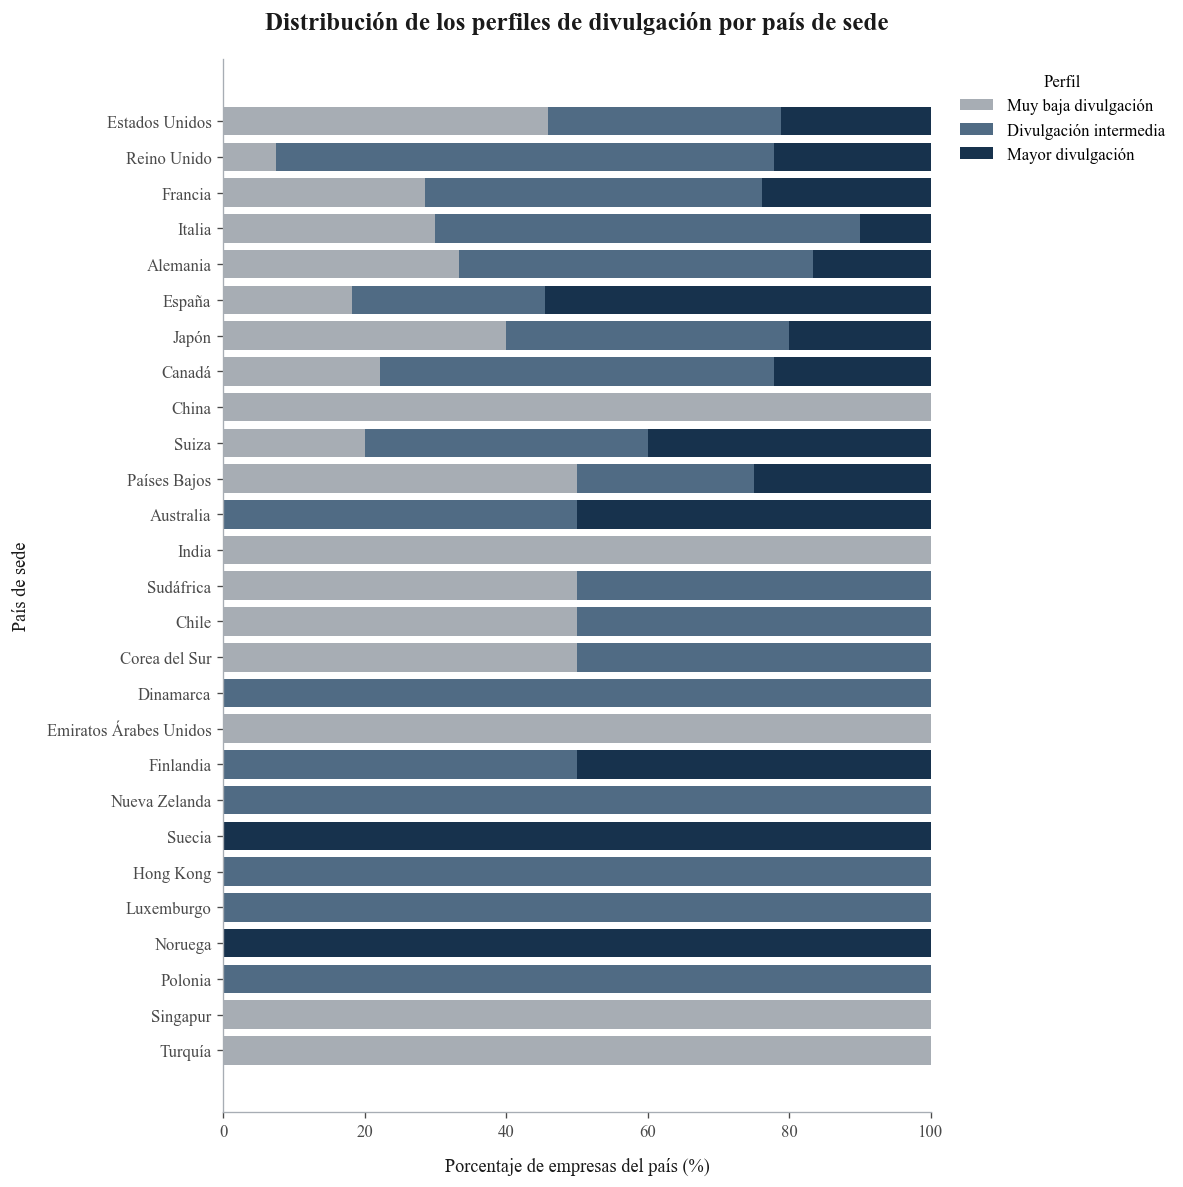

In [123]:
# Visualizamos la distribución porcentual de los tres perfiles
# de divulgación dentro de cada país de sede

# Creamos una copia con la información necesaria para la figura
distribucion_pais_grafica = (
    distribucion_pais_cluster[
        [
            "Pais_sede",
            "Total_empresas",
            "Porcentaje_Muy_baja_divulgacion",
            "Porcentaje_Divulgacion_intermedia",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
    .copy()
)

# Ordenamos los países por número total de empresas
# para mantener primero aquellos con mayor representación
distribucion_pais_grafica = (
    distribucion_pais_grafica
    .sort_values(
        "Total_empresas",
        ascending=True
    )
    .reset_index(drop=True)
)

# Definimos las posiciones de los países
posiciones = np.arange(
    len(distribucion_pais_grafica)
)

# Construimos la figura
fig, ax = plt.subplots(
    figsize=(10, 10)
)

# Primera sección: perfil de muy baja divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ],
    color=GRIS_MEDIO,
    label="Muy baja divulgación"
)

# Segunda sección: perfil de divulgación intermedia
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Divulgacion_intermedia"
    ],
    left=distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ],
    color=AZUL_SECUNDARIO,
    label="Divulgación intermedia"
)

# Calculamos la posición acumulada para la tercera sección
inicio_mayor = (
    distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ]
    +
    distribucion_pais_grafica[
        "Porcentaje_Divulgacion_intermedia"
    ]
)

# Tercera sección: perfil de mayor divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Mayor_divulgacion"
    ],
    left=inicio_mayor,
    color=AZUL_MARINO,
    label="Mayor divulgación"
)

# Incorporamos los países
ax.set_yticks(posiciones)

ax.set_yticklabels(
    distribucion_pais_grafica["Pais_sede"]
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de los perfiles de divulgación por país de sede",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de empresas del país (%)",
    labelpad=10
)

ax.set_ylabel(
    "País de sede",
    labelpad=10
)

# El eje horizontal representa porcentajes
ax.set_xlim(0, 100)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Colocamos la leyenda fuera de la gráfica
# para evitar que se superponga con las barras
ax.legend(
    frameon=False,
    title="Perfil",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_distribucion_perfiles_pais"
)

# Mostramos la figura
plt.show()

La distribución por país muestra que el **país de sede no determina por sí solo el perfil de divulgación de una empresa**. Entre los diez países que cuentan con al menos cinco empresas en la muestra, **nueve presentan empresas en los tres perfiles de divulgación**. La única excepción es **China**, cuyas nueve empresas se encuentran en el perfil de muy baja divulgación. Esto muestra que, para la mayoría de los países con mayor representación, existe heterogeneidad entre las empresas que un promedio nacional puede ocultar.

El caso de **Estados Unidos**, que concentra 85 empresas, muestra claramente esta situación: **39 empresas (45.88%)** pertenecen al perfil de muy baja divulgación, **28 (32.94%)** al perfil intermedio y **18 (21.18%)** al perfil de mayor divulgación. Por lo tanto, un mismo país puede contener empresas con patrones de transparencia considerablemente diferentes.

El clustering también permite matizar los resultados observados previamente para los países europeos. Los cinco países europeos con mayor número de empresas en la muestra (**Reino Unido, Francia, Italia, Alemania y España**) reúnen en conjunto **97 empresas**. De ellas, **53 (54.64%)** pertenecen al perfil de divulgación intermedia, **22 (22.68%)** al perfil de mayor divulgación y **22 (22.68%)** al perfil de muy baja divulgación. Por lo tanto, aun cuando estos países puedan presentar promedios nacionales relativamente elevados en el análisis exploratorio, **la mayoría de las empresas de este conjunto no pertenece al perfil de mayor divulgación**.

La composición tampoco es igual entre estos países. En **Reino Unido**, **70.37%** de las empresas pertenece al perfil intermedio; en **Francia**, **47.62%**; en **Italia**, **60.00%**; y en **Alemania**, **50.00%**. **España** presenta una distribución distinta: **54.55%** de sus empresas se ubica en el perfil de mayor divulgación, mientras que el **45.45% restante** pertenece a los perfiles intermedio o de muy baja divulgación.

Estos resultados muestran una aportación concreta del clustering al análisis: **un promedio elevado por país no implica que la mayoría de las empresas de ese país pertenezca al perfil de mayor divulgación**. El análisis por clusters permite observar la composición interna que queda oculta detrás del promedio nacional y evita interpretar el posicionamiento de un país como una característica uniforme de todas sus empresas.

Por último, los resultados de los países representados por pocas empresas deben interpretarse con cautela, ya que sus porcentajes pueden estar determinados por uno o dos casos.

### Conclusión de los perfiles identificados con K-Means

Los tres perfiles identificados **no fueron definidos a partir del porcentaje general de divulgación**, sino a partir de la similitud entre los patrones de respuesta de las empresas en los **109 indicadores binarios**. Es decir, K-Means agrupó empresas que tienden a divulgar y no divulgar información semejante. La gradación entre **muy baja, intermedia y mayor divulgación** surgió posteriormente como resultado del agrupamiento y constituye la principal estructura encontrada en los datos.

El **Cluster 0**, integrado por **91 empresas**, corresponde al perfil de **muy baja divulgación**, con un promedio general de **5.23%**. Incluso sus indicadores más frecuentes presentan porcentajes limitados: ninguno de los diez principales supera el **42.86%**, mientras que sus diez indicadores menos divulgados registran **0%**. Cuando estas empresas publican información, esta aparece principalmente en algunos mecanismos, políticas y procedimientos formales, pero gran parte de los 109 indicadores permanece sin divulgar. Por lo tanto, este perfil se caracteriza por una divulgación **reducida y selectiva**.

El **Cluster 2**, compuesto por **107 empresas**, representa el perfil de **divulgación intermedia**, con un promedio general de **27.65%**. Sin embargo, este porcentaje no significa que las empresas divulguen aproximadamente una cuarta parte de todos los temas de manera uniforme. El grupo alcanza porcentajes superiores al **85%** en determinados indicadores relacionados con políticas, responsabilidades, debida diligencia y planes ambientales, mientras que varios indicadores específicos presentan valores cercanos a **0%**. Se trata, por tanto, de empresas que ya muestran una presencia importante de ciertos mecanismos formales de transparencia, pero cuya divulgación continúa siendo limitada en otros temas.

El **Cluster 1**, integrado por **52 empresas**, corresponde al perfil de **mayor divulgación**, con un promedio general de **55.93%**. En sus diez indicadores más frecuentes, los porcentajes se encuentran entre **98.08% y 100%**, particularmente en temas relacionados con debida diligencia, riesgos e impactos, estrategias ambientales y mecanismos de gestión. Sin embargo, este grupo tampoco presenta una divulgación completa: sus diez indicadores menos frecuentes alcanzan únicamente entre **1.92% y 7.69%**. Entre estos vacíos aparecen temas relacionados con **salarios dignos, modalidades específicas de remuneración, pagos y acuerdos con proveedores**, lo que muestra que existen áreas con baja transparencia incluso entre las empresas que divulgan con mayor frecuencia.

La diferenciación entre los tres perfiles es altamente consistente. En **106 de los 109 indicadores**, el porcentaje de divulgación mantiene el orden **Cluster 1 ≥ Cluster 2 ≥ Cluster 0**. Además, los diez indicadores que más separan a los grupos presentan brechas de entre **87.91 y 97.80 puntos porcentuales**, principalmente en información ambiental y social. Esto confirma que los clusters se distinguen sobre todo por la **intensidad y amplitud de sus patrones de divulgación**, y no por especializaciones temáticas completamente opuestas.

El clustering también modifica la interpretación de los resultados obtenidos mediante el EDA. Entre los diez indicadores con mayor divulgación global, cuyos porcentajes se encuentran entre **59.60% y 75.20%**, el Cluster 1 registra entre **90.38% y 100%**, mientras que el Cluster 0 alcanza únicamente entre **12.09% y 42.86%**. Por lo tanto, un indicador puede aparecer como altamente divulgado en el conjunto de las 250 empresas y, al mismo tiempo, tener una presencia mucho menor dentro de un perfil específico. En cambio, los indicadores con menor divulgación global permanecen bajos incluso en el Cluster 1, donde ninguno supera **7.69%**. El agrupamiento permite así distinguir entre **temas cuya divulgación se concentra en ciertos perfiles** y **temas que permanecen poco divulgados de manera generalizada**.

La utilidad del agrupamiento también se observa a nivel de empresas concretas. Por ejemplo, *Vans* pertenece al Cluster 1 no simplemente porque registra **55.05% de divulgación general**, sino porque su patrón completo en los 109 indicadores es más cercano al centroide de ese perfil y porque divulga los **10 indicadores que más distinguen a los clusters**. En contraste, las empresas más representativas del Cluster 0 presentan **0% de divulgación general** y no divulgan ninguno de esos diez indicadores, mientras que las representativas del Cluster 2 divulgan entre **3 y 5**. Esto muestra que los clusters representan **patrones multidimensionales de divulgación compartidos entre empresas**, y no únicamente rangos construidos a partir de un porcentaje total.

Finalmente, el análisis por país muestra otra aportación del clustering frente a una lectura basada únicamente en promedios nacionales. Entre los diez países con al menos cinco empresas, **nueve contienen compañías pertenecientes a los tres perfiles**. Asimismo, entre **Reino Unido, Francia, Italia, Alemania y España**, que reúnen 97 empresas, **53 pertenecen al perfil intermedio, 22 al perfil de mayor divulgación y 22 al de muy baja divulgación**. Por lo tanto, un promedio nacional relativamente elevado **no implica que la mayoría de las empresas de ese país pertenezca al perfil de mayor divulgación**. El clustering permite observar la heterogeneidad entre empresas que queda oculta detrás de los promedios por país.

En conjunto, K-Means aporta una lectura adicional a la obtenida mediante el análisis exploratorio: permite pasar de conocer **cuánto se divulga en promedio** a identificar **qué empresas presentan patrones semejantes, qué información caracteriza a cada perfil, qué temas permanecen ausentes incluso entre las empresas de mayor divulgación y qué diferencias quedan ocultas detrás de los promedios globales y nacionales**. De esta manera, los clusters funcionan como una herramienta para analizar la heterogeneidad de la transparencia corporativa dentro de la muestra, más allá de un ranking general de empresas, indicadores o países.
